<a href="https://colab.research.google.com/github/parimal173/DIY_MRI_DLapproches/blob/main/Day2_Notebook_1_1_MRI_Denoising_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 1.1 — MRI Denoising + Deep Learning Foundations

    
<p style="font-size:80px;">
    

    ### Part A — Understanding MRI Data
    - Load and Inspect MRI Data
    - MRI Dimensions, Voxels, and Intensities
    - Visualize an MRI Slice
    - MRI Intensity Histogram
    - Background and Foreground
    - NumPy → PyTorch
    - Understanding `B × C × H × W`

    ### Part B — MRI Preprocessing
    - MRI Intensity Normalization
    - Min-Max, Z-Score, and Percentile Normalization
    - Cropping and Foreground Selection
    - Patch Extraction
    - Patch Size and Stride
    - Data Augmentation

    ### Part C — Creating a Denoising Problem
    - Clean MRI and Synthetic Noise
    - Gaussian Noise
    - Poisson Noise
    - Experimenting with Different Noise Levels
    - Noisy MRI → Clean MRI Training Pair

    ### Part D — Deep Learning Foundations
    - What Is a Neural Network?
    - Understanding Convolution
    - Manual Convolution Experiment
    - Building a Tiny CNN
    - CNN Tensor Shapes
    - Learnable Filters and Parameters
    - Activation Functions

    ### Part E — CNN Architecture for Image Restoration
    - Pooling
    - Upsampling
    - Encoder–Decoder Architecture
    - Why Our First Denoising CNN Keeps the Same Image Size

    ### Part F — Supervised MRI Denoising
    - Forward Pass
    - Network Output Before Training
    - Loss Functions
    - MSE Loss
    - MAE / L1 Loss
    - Smooth L1 / Huber Loss
    - Perceptual Loss — Concept
    - Training the CNN
    - Backpropagation
    - Optimizer and Parameter Updates
    - Training for Multiple Steps

    ### Part G — Evaluating Denoising
    - MSE and MAE
    - PSNR
    - SSIM
    - LPIPS — Concept
    - Edge / Gradient Preservation
    - Visual Comparison
    - Understanding Denoising Artifacts

    ### Part H — Complete Supervised Denoising Pipeline
    - Noisy MRI → CNN → Denoised MRI
    - Compare with Clean MRI
    - Calculate Evaluation Metrics
    - Visualize the Final Result
    - What Did the Network Learn?

    ### Part I — From Supervised to Zero-Shot Denoising
    - Limitations of Supervised Denoising
    - Why Do We Need a Clean MRI?
    - What If Only One Noisy MRI Is Available?
    - Masking and Self-Supervision
    - Supervised vs Zero-Shot Denoising
    - Preview of Notebook 1.2 — Zero-Shot Denoising
</p>
    

In [1]:
# from google.colab import drive
# drive.mount('/drive')

In [2]:
# cd /drive/MyDrive/

In [3]:
!git clone https://github.com/ajaynice1996/DIY_MRI_Workshop_II_Recon

fatal: destination path 'DIY_MRI_Workshop_II_Recon' already exists and is not an empty directory.


# Print working directory

In [4]:
!pwd

/content


# Import header files

In [5]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


# Module 0: Understanding low-field MRI phantom; How it look like


### Load Phantom NIfTI Data
<p style="font-size:100px;">

This cell locates and loads a NIfTI (`.nii.gz`) phantom image from the workshop training-data directory.

    The workflow:
    1. Defines the workshop and phantom directories.
    2. Searches for available `.nii.gz` files.
    3. Selects the first NIfTI file found.
    4. Loads the image using `nibabel`.
    5. Converts the image data to `float32` for compatibility with NumPy/PyTorch processing.
    6. Prints an error message if no valid NIfTI file is found.

The resulting 3D image volume is stored in `volume_phantom`.

</p>

In [6]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import torch
import glob

# Define the workshop root directory based on previous cells
workshop_root_dir = "/content/DIY_MRI_Workshop_II_Recon/data/Training_data"
phantom_dir = os.path.join(workshop_root_dir, "phantom")

# Find a NIfTI file in the phantom directory
nifti_files = glob.glob(os.path.join(phantom_dir, "*.nii.gz"))

if not nifti_files:
    print(f"Error: No NIfTI files found in {phantom_dir}")
    # Exit or handle error, for now, we'll assume a file exists
    # or create a placeholder for a specific phantom file.
    # For demonstration, let's assume a file name if none found in glob.
    # In a real scenario, you might want to stop or ask for user input.
    image_path_phantom = os.path.join(phantom_dir, "phantom_data.nii.gz") # Fallback name
else:
    image_path_phantom = nifti_files[0] # Take the first found NIfTI file

print("Loading phantom data from:", image_path_phantom)

# Load NIfTI
try:
    nii_phantom = nib.load(image_path_phantom)
    volume_phantom = nii_phantom.get_fdata().astype(np.float32)
except FileNotFoundError:
    print(f"Error: NIfTI file not found at {image_path_phantom}. Please check the path and file name.")
    volume_phantom = None


Loading phantom data from: /content/DIY_MRI_Workshop_II_Recon/data/Training_data/phantom/Phantom_2_resampled_2.0x2.0x2.0mm_resampled_2.0x2.0x2.0mm.nii.gz


### Phantom MRI Properties
<p style="font-size:100px;">
Display the volume dimensions, voxel spacing, data type, and basic intensity statistics.
</p>

In [7]:
# Basic information
print("\nPhantom MRI information")
print("-----------------------")
print("Shape:", volume_phantom.shape)
print("Voxel spacing:", nii_phantom.header.get_zooms()[:3])
print("Data type:", volume_phantom.dtype)
print("Minimum intensity:", volume_phantom.min())
print("Maximum intensity:", volume_phantom.max())
print("Mean intensity:", volume_phantom.mean())
print("Standard deviation:", volume_phantom.std())


Phantom MRI information
-----------------------
Shape: (110, 110, 80)
Voxel spacing: (np.float32(2.0), np.float32(2.0), np.float32(2.0))
Data type: float32
Minimum intensity: -38.926056
Maximum intensity: 2074.5571
Mean intensity: 294.7305
Standard deviation: 385.84015


### Normalize and Visualize

Apply min-max normalization to the phantom volume and display the middle slice before and after normalization.


Min-max normalized phantom range: 0.0 to 1.0


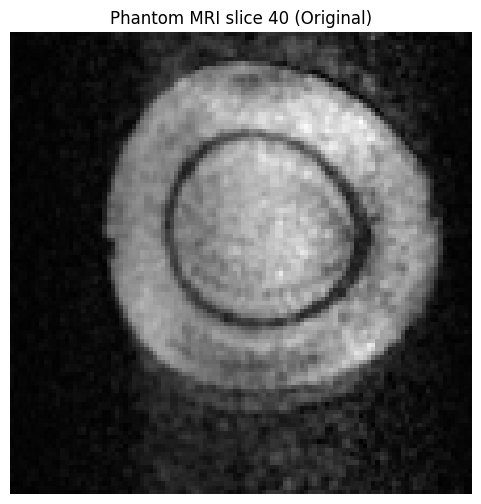

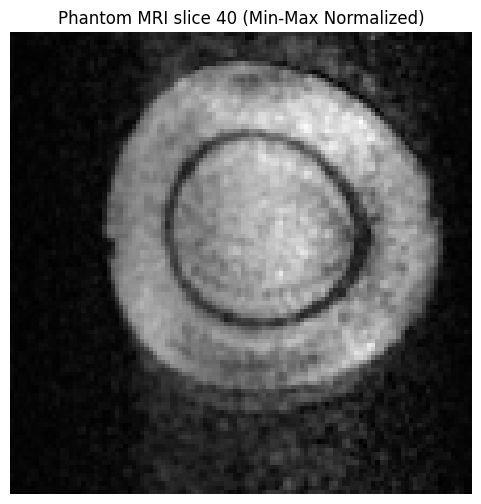

In [8]:
# Min-max normalization
volume_phantom_minmax = (volume_phantom - volume_phantom.min()) / \
                        (volume_phantom.max() - volume_phantom.min() + 1e-8)
print("\nMin-max normalized phantom range:", volume_phantom_minmax.min(), "to", volume_phantom_minmax.max())

# Select the middle slice
slice_idx_phantom = volume_phantom.shape[2] // 2
image_2d_phantom = volume_phantom[:, :, slice_idx_phantom]
image_2d_phantom_minmax = volume_phantom_minmax[:, :, slice_idx_phantom]

# Display original middle slice
plt.figure(figsize=(6, 6))
plt.imshow(image_2d_phantom.T, cmap="gray", origin='lower')
plt.title(f"Phantom MRI slice {slice_idx_phantom} (Original)")
plt.axis("off")
plt.show()

# Display normalized middle slice
plt.figure(figsize=(6, 6))
plt.imshow(image_2d_phantom_minmax.T, cmap="gray", origin='lower')
plt.title(f"Phantom MRI slice {slice_idx_phantom} (Min-Max Normalized)")
plt.axis("off")
plt.show()



# SNR Computation

Signal-to-Noise Ratio (SNR) measures how strong the desired MRI signal is relative to background noise. A higher SNR generally indicates that the anatomical or phantom signal is more distinguishable from noise.

For an image, SNR can be estimated by selecting:

    Signal ROI: a region containing the object/anatomy of interest.

    Noise ROI: a background region containing little or no true signal.



Calculated SNR for Phantom (middle slice): 55.33


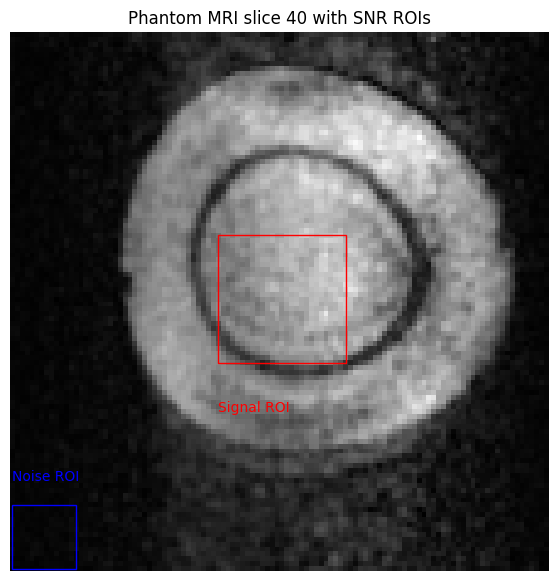

In [9]:
# Compute SNR on the middle slice
# Define a signal ROI (e.g., a central square)
h_phantom, w_phantom = image_2d_phantom.shape
signal_roi_size = min(h_phantom, w_phantom) // 4
signal_roi_start_h = h_phantom // 2 - signal_roi_size // 2
signal_roi_end_h = h_phantom // 2 + signal_roi_size // 2
signal_roi_start_w = w_phantom // 2 - signal_roi_size // 2
signal_roi_end_w = w_phantom // 2 + signal_roi_size // 2

signal_roi = image_2d_phantom[
    signal_roi_start_h:signal_roi_end_h,
    signal_roi_start_w:signal_roi_end_w
]

# Define a noise ROI (e.g., a corner, assuming it's background/air)
# Taking a top-left corner region for noise
noise_roi_size = min(h_phantom, w_phantom) // 8
noise_roi = image_2d_phantom[
    0:noise_roi_size,
    0:noise_roi_size
]

mean_signal = np.mean(signal_roi)
std_noise = np.std(noise_roi)

# Avoid division by zero if std_noise is very small
snr_phantom = mean_signal / (std_noise + 1e-8) if std_noise != 0 else float('inf')

print(f"\nCalculated SNR for Phantom (middle slice): {snr_phantom:.2f}")

# Visualize ROIs for SNR
plt.figure(figsize=(7, 7))
plt.imshow(image_2d_phantom.T, cmap="gray", origin='lower')
plt.title(f"Phantom MRI slice {slice_idx_phantom} with SNR ROIs")
plt.axis("off")

# Draw signal ROI
rect_signal = plt.Rectangle((signal_roi_start_w, signal_roi_start_h),
                            signal_roi_end_w - signal_roi_start_w,
                            signal_roi_end_h - signal_roi_start_h,
                            linewidth=1, edgecolor='r', facecolor='none')
plt.gca().add_patch(rect_signal)
plt.text(signal_roi_start_w, signal_roi_start_h - 10, 'Signal ROI', color='r', fontsize=10)

# Draw noise ROI
rect_noise = plt.Rectangle((0, 0),
                            noise_roi_size,
                            noise_roi_size,
                            linewidth=1, edgecolor='b', facecolor='none')
plt.gca().add_patch(rect_noise)
plt.text(0, noise_roi_size + 5, 'Noise ROI', color='b', fontsize=10)

plt.show()


# Understand Original resolution and resampling of phantom data

## Resample Phantom MRI

Resample the phantom volume to different voxel spacings using cubic interpolation and save each resampled NIfTI image for later reconstruction experiments.

Original phantom image loaded from: /content/DIY_MRI_Workshop_II_Recon/data/Training_data/phantom/Phantom_2_resampled_2.0x2.0x2.0mm_resampled_2.0x2.0x2.0mm.nii.gz
Original shape: (110, 110, 80), Voxel spacing: (np.float32(2.0), np.float32(2.0), np.float32(2.0))

Resampling to new voxel spacing: (1.0, 1.0, 2.0) mm
Saved resampled image to: /content/DIY_MRI_Workshop_II_Recon/data/Training_data/phantom/Phantom_2_resampled_2.0x2.0x2.0mm_resampled_2.0x2.0x2.0mm_resampled_1.0x1.0x2.0mm.nii.gz
New image shape: (220, 220, 80), New voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(2.0))

Resampling to new voxel spacing: (1.0, 1.0, 5.0) mm
Saved resampled image to: /content/DIY_MRI_Workshop_II_Recon/data/Training_data/phantom/Phantom_2_resampled_2.0x2.0x2.0mm_resampled_2.0x2.0x2.0mm_resampled_1.0x1.0x5.0mm.nii.gz
New image shape: (220, 220, 32), New voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(5.0))

Resampling to new voxel spacing: (2.0, 2.0, 2.0) mm
Saved resampled i

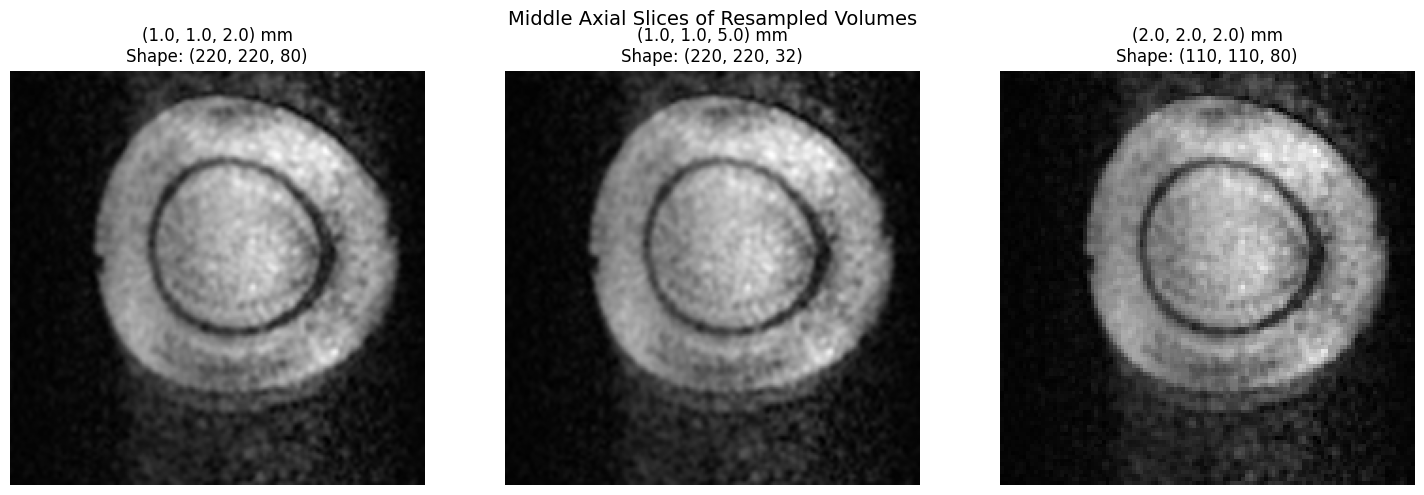

In [10]:
import numpy as np
import nibabel as nib

import scipy.ndimage
import os

def resample_nifti_image(nifti_img, new_voxel_spacing, interpolation_order=3):
    """
    Resamples a NIfTI image to a new voxel spacing.

    Parameters
    ----------
    nifti_img : nibabel.Nifti1Image
        The input NIfTI image object.
    new_voxel_spacing : tuple
        A tuple (sx, sy, sz) representing the desired new voxel spacing in mm.
    interpolation_order : int, optional
        The order of interpolation (0-5) for scipy.ndimage.zoom.
        0: Nearest-neighbor, 1: Linear, 3: Cubic (default).

    Returns
    -------
    nibabel.Nifti1Image
        The resampled NIfTI image object.
    """
    original_data = nifti_img.get_fdata()
    original_affine = nifti_img.affine
    original_header = nifti_img.header
    original_zooms = original_header.get_zooms()[:3]

    # Calculate zoom factors for scipy.ndimage.zoom
    zoom_factors = [
        original_zooms[i] / new_voxel_spacing[i]
        for i in range(len(new_voxel_spacing))
    ]

    # Resample the image data
    resampled_data = scipy.ndimage.zoom(
        original_data,
        zoom_factors,
        order=interpolation_order
    )

    # Update the affine matrix to reflect the new voxel spacing
    # nibabel.affines.rescale_affine recomputes the affine based on original affine, original shape, and new zooms
    new_affine = nib.affines.rescale_affine(
        original_affine,
        original_data.shape,
        new_voxel_spacing
    )

    # Create a new NIfTI image with the resampled data and updated affine
    new_nifti = nib.Nifti1Image(resampled_data, new_affine, original_header)

    # Update the pixel dimensions in the header for consistency
    new_nifti.header['pixdim'][1:4] = new_voxel_spacing

    return new_nifti


# --- Resampling and Saving --- #

# Check if nii_phantom (from previous cell) is available
if 'nii_phantom' not in locals() or nii_phantom is None:
    print("Error: Original NIfTI phantom image 'nii_phantom' not found. Please run the previous cells first.")
else:
    print(f"Original phantom image loaded from: {image_path_phantom}")
    print(f"Original shape: {nii_phantom.shape}, Voxel spacing: {nii_phantom.header.get_zooms()[:3]}")

    # Define target voxel spacings
    target_spacings = [
        (1.0, 1.0, 2.0),
        (1.0, 1.0, 5.0),
        (2.0, 2.0, 2.0)
    ]

    # Directory to save resampled images (using the phantom_dir from previous cell)
    output_dir = phantom_dir
    os.makedirs(output_dir, exist_ok=True)

    fig, axes = plt.subplots(1, len(target_spacings), figsize=(15, 5))

    for idx, spacing in enumerate(target_spacings):
        print(f"\nResampling to new voxel spacing: {spacing} mm")

        # Resample the image
        resampled_nii = resample_nifti_image(nii_phantom, spacing)

        resampled_data = resampled_nii.get_fdata()

        # Construct output filename
        base_name = os.path.basename(image_path_phantom)
        name_without_ext = os.path.splitext(base_name)[0]

        # Handle .nii.gz extension separately
        if name_without_ext.endswith('.nii'):
            name_without_ext = os.path.splitext(name_without_ext)[0]

        output_filename = f"{name_without_ext}_resampled_{spacing[0]}x{spacing[1]}x{spacing[2]}mm.nii.gz"
        output_path = os.path.join(output_dir, output_filename)

        # Save the resampled image
        nib.save(resampled_nii, output_path)
        print(f"Saved resampled image to: {output_path}")
        print(f"New image shape: {resampled_nii.shape}, New voxel spacing: {resampled_nii.header.get_zooms()[:3]}")

        mid_slice_z = resampled_data.shape[2] // 2

        # Plot onto the current axis
        ax = axes[idx]
        ax.imshow(resampled_data[:, :, mid_slice_z].T, cmap='gray', origin='lower')
        ax.set_title(f"{spacing} mm\nShape: {resampled_data.shape}")
        ax.axis('off')

    plt.suptitle("Middle Axial Slices of Resampled Volumes", fontsize=14)
    plt.tight_layout()
    plt.show()


# Module 1 — Understand the MRI Data - Game on

## Lets Switch to Human Brain Image for understanding of concepts -- This Notebook help you understand the Deep learning pipeline and components for image denoising using CNNs.

    ### Goal: What is the models actually receiving?

    Before building a neural network, we first need to understand the MRI data.

    An MRI scanner produces an image volume, but an algorithm sees patterns in the image.

    In this module we will:

    1. Load a high-field MRI
    2. Inspect its dimensions and voxel spacing
    3. Display the MRI slice
    4. Examine the intensity values
    5. Look at the intensity histogram
    6. Identify background and foreground
    7. Convert the MRI from NumPy to PyTorch tensor
    8. Understand the tensor shape required by a CNN

The key idea is:

**MRI volume → MRI slice → array of numbers → PyTorch tensor → CNN input**

In [11]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import torch

# Workshop root directory
workshop_dir = "/content/DIY_MRI_Workshop_II_Recon/data/Training_data/POCEMR001"

# Select image
image_path = os.path.join(
    workshop_dir,
    "3T",
    "POCEMR001_T2.nii.gz"
)

print("Loading:", image_path)

# Load NIfTI
nii = nib.load(image_path)

# Convert to NumPy array
volume = nii.get_fdata().astype(np.float32)

# Basic information
print("\nMRI information")
print("----------------")
print("Shape:", volume.shape)
print("Voxel spacing:", nii.header.get_zooms()[:3])
print("Data type:", volume.dtype)
print("Minimum intensity:", volume.min())
print("Maximum intensity:", volume.max())
print("Mean intensity:", volume.mean())
print("Standard deviation:", volume.std())

Loading: /content/DIY_MRI_Workshop_II_Recon/data/Training_data/POCEMR001/3T/POCEMR001_T2.nii.gz

MRI information
----------------
Shape: (224, 224, 160)
Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Data type: float32
Minimum intensity: 0.0
Maximum intensity: 255.0
Mean intensity: 38.78939
Standard deviation: 53.17793


  ## What does the MRI shape mean?

  Suppose the MRI has shape:

      H × W × D

  For example:

      512 × 512 × 30

  This means the MRI is a 3D volume containing 30 image slices.

  Lets conside the slice:

      H × W

  For example:

      512 × 512

  Each location contains a numerical intensity value.

  So an MRI is essentially:

      MRI
      ↓
      3D array of numbers
      ↓
      individual 2D slices

  ### Important distinction

  - **Pixel** → a value in a 2D image
  - **Voxel** → a value in a 3D MRI volume
  - **Voxel spacing** → physical size of each voxel
  - **Intensity** → numerical value representing the measured MRI signal

  The same MRI can therefore be viewed both as an image and as a numerical dataset.

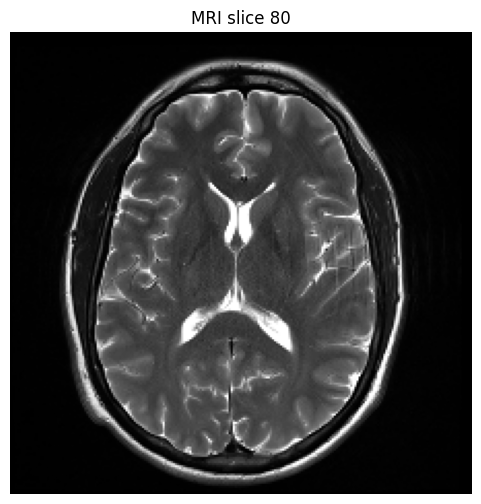

In [12]:
# Select the middle slice
slice_idx = volume.shape[2] // 2
image_2d = volume[:, :, slice_idx]

plt.figure(figsize=(6, 6))
plt.imshow(image_2d.T, cmap="gray", origin='lower')
plt.title(f"MRI slice {slice_idx}")
plt.axis("off")
plt.show()

    The MRI intensity histogram is important because it helps us:

    Understand the intensity distribution of the MRI.
    Identify background vs. tissue signal.
    Detect outliers or unusual intensity values.
    Decide whether normalization/clipping is needed.
    
    Simply: it tells us what intensity values are present
    and how frequently they occur before processing the MRI.

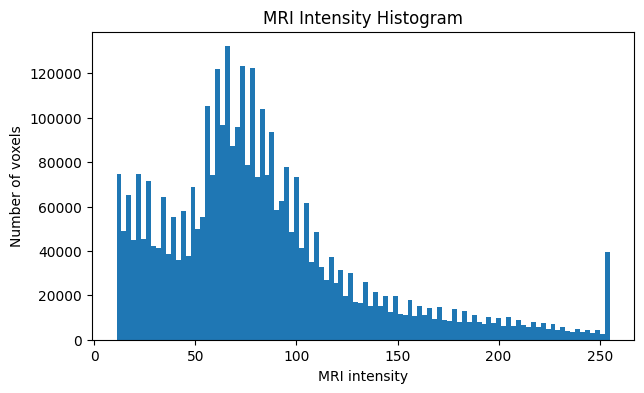

In [13]:
plt.figure(figsize=(7, 4))
plt.hist(volume[volume > 10].ravel(), bins=100)
plt.xlabel("MRI intensity")
plt.ylabel("Number of voxels")
plt.title("MRI Intensity Histogram")
plt.show()

# Why is thresholding important in MRI ?

    Thresholding helps separate the anatomical region of interest from the background.

    Removes very low-intensity voxels that are often
    
    background or noise.

    Can Reduce unnecessary data outside the object being
    imaged.

    Makes segmentation and subsequent image processing
    easier.
    Can reduce the influence of background noise on
    reconstruction or analysis.

    Helps focus computational methods on the meaningful MRI
    signal.

In simple terms:

    Thresholding can remove pixels/voxels that are outside
    the useful intensity range, allowing us to focus on the
    actual anatomy rather than background noise.

    Note: A simple threshold such as 0.1 × max intensity is
    mainly for demonstrating the concept. In real MRI
    processing, the threshold should be chosen carefully
    because low-intensity anatomical structures can also
    contain useful information.

Total voxels: 8028160
Foreground voxels: 559580
Background voxels: 7468580


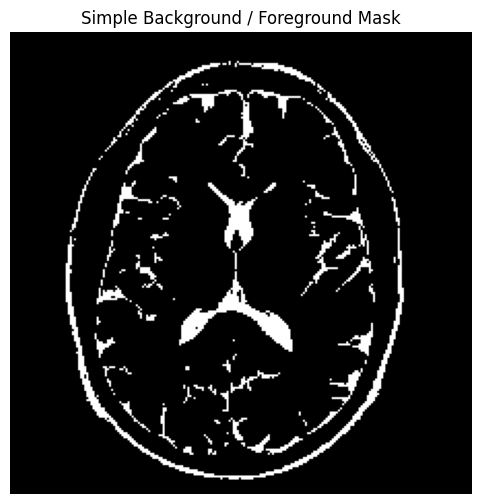

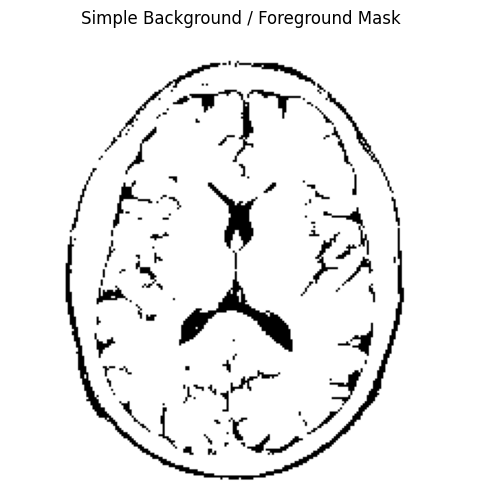

In [14]:
# Simple threshold only for understanding the concept
threshold = 0.5 * volume.max()

foreground = volume > threshold
background = ~foreground

print("Total voxels:", volume.size)
print("Foreground voxels:", foreground.sum())
print("Background voxels:", (~foreground).sum())

plt.figure(figsize=(6, 6))
plt.imshow(foreground[:, :, slice_idx].T, cmap="gray", origin='lower')
plt.title("Simple Background / Foreground Mask")
plt.axis("off")
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(background[:, :, slice_idx].T, cmap="gray", origin='lower')
plt.title("Simple Background / Foreground Mask")
plt.axis("off")
plt.show()

## Pixel vs. Voxel

- **Pixel:** A small element in a **2D MRI slice**. It contains one intensity value.  
  **Example:** Pixel = `95`

- **Voxel:** A small element in a **3D MRI volume**. It contains one intensity value and represents a small volume of tissue.  
  **Example:** Voxel = `95`

**In short:**  
**Pixel → 2D image**  
**Voxel → 3D volume**

# Numpy to Pytorch tensor

    Because PyTorch models cannot directly process NumPy
    arrays. We convert the MRI data to a PyTorch tensor so
    it can be used for deep learning.

In [15]:
# MRI slice as a NumPy array
print("NumPy")
print("Shape:", image_2d.shape)
print("Type:", type(image_2d))

# Convert to PyTorch tensor
image_tensor = torch.from_numpy(image_2d)

print("\nPyTorch")
print("Shape:", image_tensor.shape)
print("Type:", type(image_tensor))

NumPy
Shape: (224, 224)
Type: <class 'numpy.ndarray'>

PyTorch
Shape: torch.Size([224, 224])
Type: <class 'torch.Tensor'>


# From MRI Slice to CNN Input

A CNN expects image data in a specific tensor format.

Start with one MRI slice:

    MRI slice

        ↓

    H × W

Example:

    512 × 512


But a CNN also needs to know how many image channels there are.

A grayscale MRI has:

    1 channel

So we add a channel dimension:

    H × W
       ↓
    C × H × W

    512 × 512
       ↓
    1 × 512 × 512


Finally, CNNs are normally trained using batches of images.

So we add a batch dimension:

    C × H × W
       ↓
    B × C × H × W

Therefore:

    512 × 512
       ↓
    1 × 512 × 512
       ↓
    1 × 1 × 512 × 512


Where:

- **B** = batch size
- **C** = number of channels
- **H** = image height
- **W** = image width

For one grayscale MRI slice:

    B = 1
    C = 1

This gives:

    1 × 1 × 512 × 512

This is the format that CNN will receive.

In [16]:
# H × W
image_tensor = torch.from_numpy(image_2d.astype(np.float32))

# Add channel dimension: C × H × W
image_ch = image_tensor.unsqueeze(0)

# Add batch dimension: B × C × H × W
image_batch = image_ch.unsqueeze(0)

print("Original:")
print(image_tensor.shape)

print("\nAfter adding channel:")
print(image_ch.shape)

print("\nAfter adding batch:")
print(image_batch.shape)

Original:
torch.Size([224, 224])

After adding channel:
torch.Size([1, 224, 224])

After adding batch:
torch.Size([1, 1, 224, 224])


    There can be bach more than 1.

  ## Module 1 — What did we learn? For single slice information

  The simple journey is:

      MRI volume
          ↓
      select one slice
          ↓
      H × W
          ↓
      add channel
          ↓
      C × H × W
          ↓
      add batch
          ↓
      B × C × H × W
          ↓
      CNN


  For our example:

      512 × 512
          ↓
      1 × 512 × 512
          ↓
      1 × 1 × 512 × 512


  ### Check your understanding

  Before moving on, you should be able to answer:

  1. What does each number in an MRI array represent?
  2. What is the difference between a pixel and a voxel?
  3. What do C, and B mean?
  4. Why does a grayscale MRI have C = 1?
  5. Why do we add a batch dimension?
  6. What shape will our CNN receive?

  **Next:** We will normalize the MRI intensities to a simple **0–1 range**, and see how the numerical values change.

  # Module 2 — MRI Normalization

  ### Goal: Put MRI intensities into a useful numerical range

  MRI intensity values can have very different numerical ranges.

  For example, one MRI might contain values from:

      0 → 2500

  while another MRI might have a completely different range.

  Neural networks generally work better when input values are placed on a more predictable numerical scale.

  We will compare three common approaches:

  1. **Min-max normalization**
  2. **Z-score normalization**
  3. **Percentile normalization**

  We will visualize how each method changes the MRI.

  For our later denoising experiments, we will use:

  **Min-max normalization → [0, 1]**

In [17]:
# Use the same MRI slice from Module 1
image = image_2d.astype(np.float32)

print("Original range:", image.min(), "to", image.max())
print("Original mean:", image.mean())
print("Original std:", image.std())

Original range: 0.0 to 255.0
Original mean: 44.239735
Original std: 53.888557


## A. Min-max normalization

Min-max normalization maps the minimum value to 0
and the maximum value to 1.

    normalized = (image - min) / (max - min)

Therefore:

    minimum → 0
    maximum → 1

This is simple and easy to understand.

We will use this version for our main workshop training experiment.

Min-max range: 0.0 to 1.0


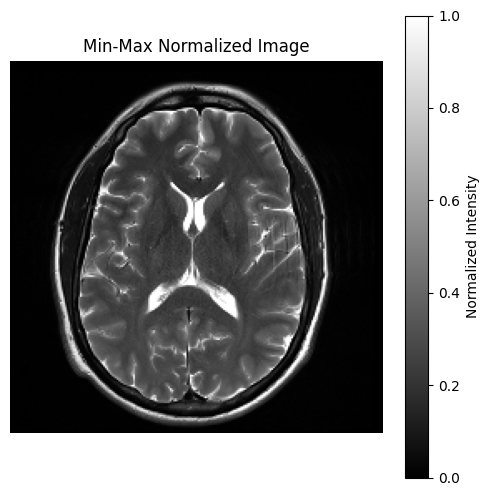

In [18]:
image_minmax = (
    image - image.min()
) / (
    image.max() - image.min() + 1e-8
)

print("Min-max range:", image_minmax.min(), "to", image_minmax.max())
plt.figure(figsize=(6, 6))
im = plt.imshow(image_minmax.T, cmap="gray", origin="lower")

plt.title("Min-Max Normalized Image")
plt.colorbar(im, label="Normalized Intensity")
plt.axis("off")
plt.show()

## B. Z-score normalization

Z-score normalization centers the image around its mean
and scales it according to its standard deviation.

    z = (x - mean) / std

After normalization:

    mean ≈ 0
    standard deviation ≈ 1

Unlike min-max normalization, the values are not restricted
to the range [0, 1].

Z-score range: -0.8209486 to 3.9110394
Mean: 9.73137e-09
Std: 1.0


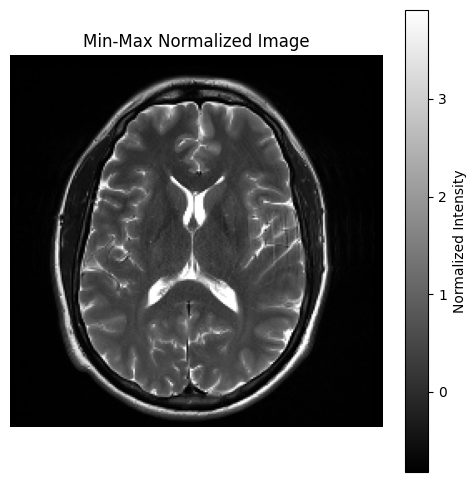

In [19]:
image_zscore = (
    image - image.mean()
) / (
    image.std() + 1e-8
)

print("Z-score range:", image_zscore.min(), "to", image_zscore.max())
print("Mean:", image_zscore.mean())
print("Std:", image_zscore.std())

plt.figure(figsize=(6, 6))
im = plt.imshow(image_zscore.T, cmap="gray", origin="lower")

plt.title("Min-Max Normalized Image")
plt.colorbar(im, label="Normalized Intensity")
plt.axis("off")
plt.show()

## C. Percentile normalization

Another approach is to first remove extreme intensity values.

For example:

    1st percentile → lower limit
    99th percentile → upper limit

Values below the 1st percentile are clipped to the lower limit.

Values above the 99th percentile are clipped to the upper limit.

The result is then scaled to [0, 1].

This can reduce the influence of extreme outliers.

1st percentile: 0.0
99th percentile: 255.0
Range: 0.0 to 0.9999999999607843


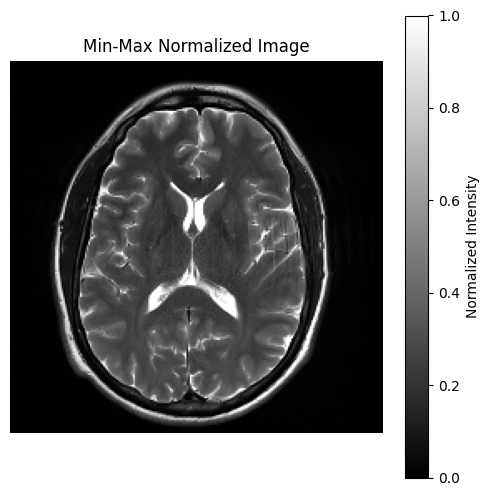

In [20]:
p1, p99 = np.percentile(image, [1, 99])

image_percentile = np.clip(image, p1, p99)

image_percentile = (
    image_percentile - p1
) / (
    p99 - p1 + 1e-8
)

print("1st percentile:", p1)
print("99th percentile:", p99)
print("Range:", image_percentile.min(), "to", image_percentile.max())

plt.figure(figsize=(6, 6))
im = plt.imshow(image_percentile.T, cmap="gray", origin="lower")

plt.title("Min-Max Normalized Image")
plt.colorbar(im, label="Normalized Intensity")
plt.axis("off")
plt.show()

    # How does normalization change the MRI?

    Let's look at the same MRI slice before and after normalization.

    The anatomy should remain recognizable.

    What changes is primarily the **numerical representation of intensity**.

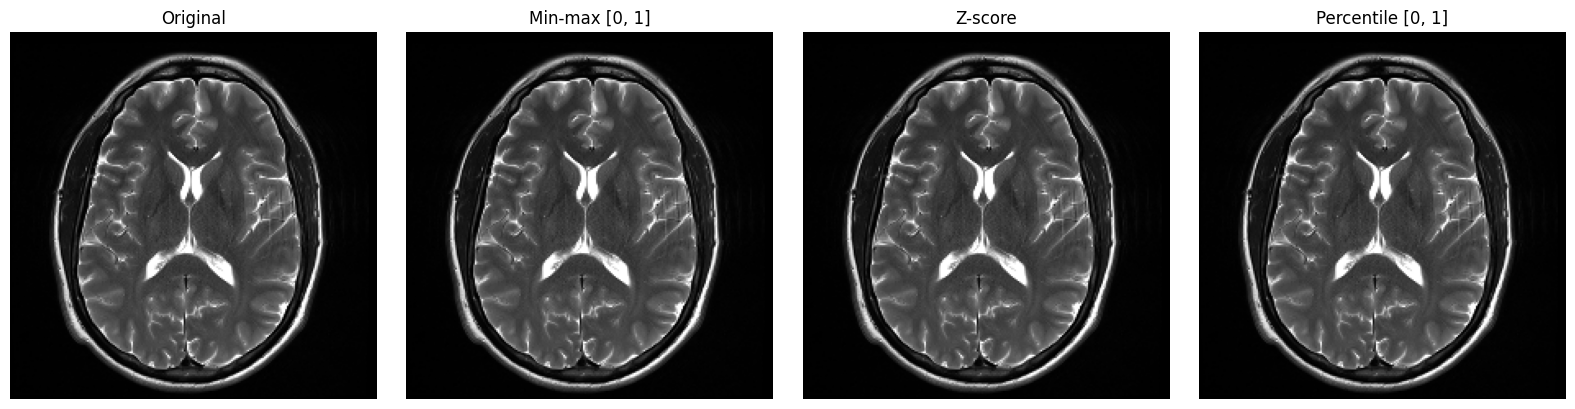

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

images = [
    image,
    image_minmax,
    image_zscore,
    image_percentile
]

titles = [
    "Original",
    "Min-max [0, 1]",
    "Z-score",
    "Percentile [0, 1]"
]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img.T, cmap="gray", origin = 'lower')
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

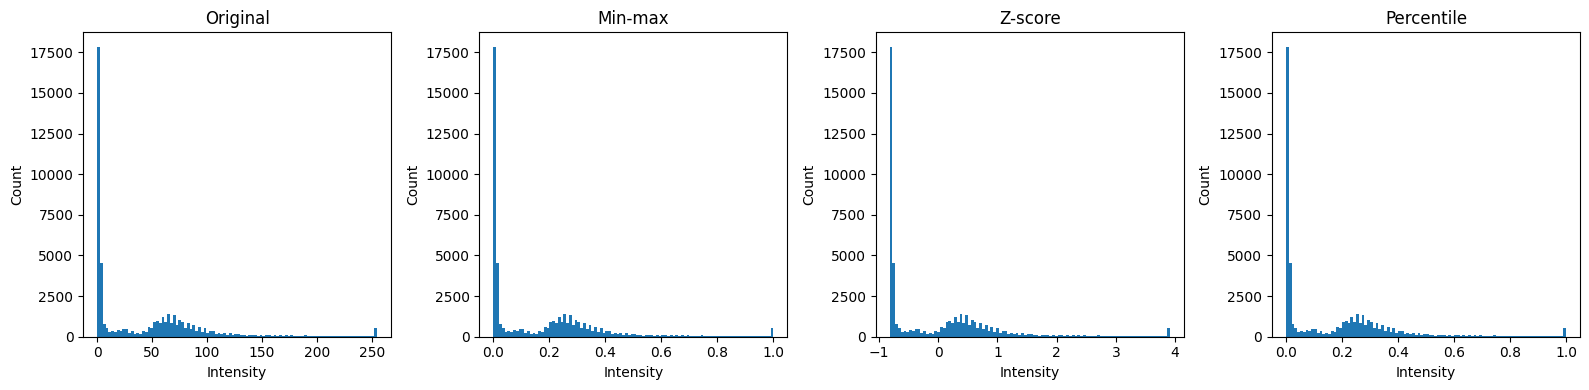

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

data = [
    image.ravel(),
    image_minmax.ravel(),
    image_zscore.ravel(),
    image_percentile.ravel()
]

titles = [
    "Original",
    "Min-max",
    "Z-score",
    "Percentile"
]

for ax, values, title in zip(axes, data, titles):
    ax.hist(values.ravel(), bins=100)
    ax.set_title(title)
    ax.set_xlabel("Intensity")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

# Why do neural networks benefit from normalized inputs?

    Normalization can help because neural networks learn from numerical values.

    If input values have very large or inconsistent scales:

    - optimization can become less convenient
    - gradients can have less favorable scales
    - learning rates become harder to choose consistently
    - training can be more sensitive to the intensity range

    Putting inputs into a predictable range makes the learning problem easier to manage.

    However, normalization does **not** mean that the MRI becomes "better."

    It changes the numerical representation of the image.

    ### Important MRI point

    MRI intensities are not standardized in the same way as many natural-image
    pixel values.

    Therefore, normalization is an important part of an MRI deep-learning
    pipeline, especially when comparing images from different scanners,
    field strengths, subjects, or acquisitions.


In [23]:
print("Normalization summary")
print("---------------------")

for name, img in [
    ("Original", image),
    ("Min-max", image_minmax),
    ("Z-score", image_zscore),
    ("Percentile", image_percentile)
]:
    print(
        f"{name:12s} | "
        f"min={img.min():7.3f} | "
        f"max={img.max():7.3f} | "
        f"mean={img.mean():7.3f} | "
        f"std={img.std():7.3f}"
    )

Normalization summary
---------------------
Original     | min=  0.000 | max=255.000 | mean= 44.240 | std= 53.889
Min-max      | min=  0.000 | max=  1.000 | mean=  0.173 | std=  0.211
Z-score      | min= -0.821 | max=  3.911 | mean=  0.000 | std=  1.000
Percentile   | min=  0.000 | max=  1.000 | mean=  0.173 | std=  0.211


  ## Student exercise

  Look at the four images and four histograms.

  Answer:

  1. Which normalization produces values between 0 and 1?
  2. Which normalization produces a mean close to 0?
  3. Which normalization is affected by extreme intensity values?
  4. Does normalization change the anatomy?
  5. Why might a predictable intensity range help CNN training?

  ### Our choice for this workshop

  We will use:

      Min-max normalization
              ↓
          [0, 1]

  for the main denoising experiment.

  We will keep Z-score and percentile normalization as important
  alternative strategies that students should understand.

  ---

  

  # Module 3 — Crop, Foreground & Patch Generation

### From an MRI Image to Training Examples

CNNs often do not need to process an entire MRI volume at once.  
Instead, we can divide the image into smaller **patches**.

This reduces computational and memory requirements while providing multiple training examples.

**Workflow:**

MRI slice  
↓  
Image patches  
↓  
Training examples  
↓  
CNN

  

### One MRI image can become many training examples

  Start with one MRI slice:

  **H × W**

  ↓

  Divide it into smaller regions:

  **64 × 64 patches**

  For example, conceptually:

  ```text
          H × W MRI
  ┌────┬────┬────┬────┐
  │    │    │    │    │
  ├────┼────┼────┼────┤
  │    │    │    │    │
  ├────┼────┼────┼────┤
  │    │    │    │    │
  └────┴────┴────┴────┘
        64 × 64

In [24]:
H, W = image_minmax.shape
patch_size = 64

print("H =", H)
print("W =", W)

print("Patches along height:", H // patch_size)
print("Patches along width:", W // patch_size)
print("Total non-overlapping patches:",
      (H // patch_size) * (W // patch_size))

H = 224
W = 224
Patches along height: 3
Patches along width: 3
Total non-overlapping patches: 9


    **Patch-based learning gives the CNN many examples from a single MRI image.**

    It is also important for zero-shot denoising, where patches can be
    masked and the network learns to predict missing pixels from the surrounding information.


  ### Student thinking exercise

  ```markdown
  ## 🧠 Think About It

  Suppose your MRI slice has size **H × W** and you use **64 × 64** patches.

  1. What happens to the number of patches if you make the stride smaller?
  2. Which gives more patches: **stride = 64** or **stride = 32**?
  3. Why might you want to remove patches that contain almost only background?

  **Think:**  
  More patches → more training examples, but also more computation.

  ➡️ Next: **How do we actually extract these patches from the MRI?**

  # Module 4 — Data Augmentation

  ### Create variation from the same MRI

  Before adding noise, we can create slightly different versions of an image.

  ```text
  Original MRI
      ↓
  Augmentation
      ↓
  New training example

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Use the normalized MRI image from Module 2
image = image_minmax.copy()

# 1. Horizontal flip
flip_horizontal = np.fliplr(image)

# 2. Vertical flip
flip_vertical = np.flipud(image)

# 3. 90° rotation
rotate_90 = np.rot90(image)

# 4. Small rotation
# Requires scipy
from scipy.ndimage import rotate

rotate_small = rotate(
    image,
    angle=10,
    reshape=False,
    mode="nearest"
)

# 5. Intensity perturbation
intensity_change = np.clip(
    image * 1.10,
    0,
    1
)

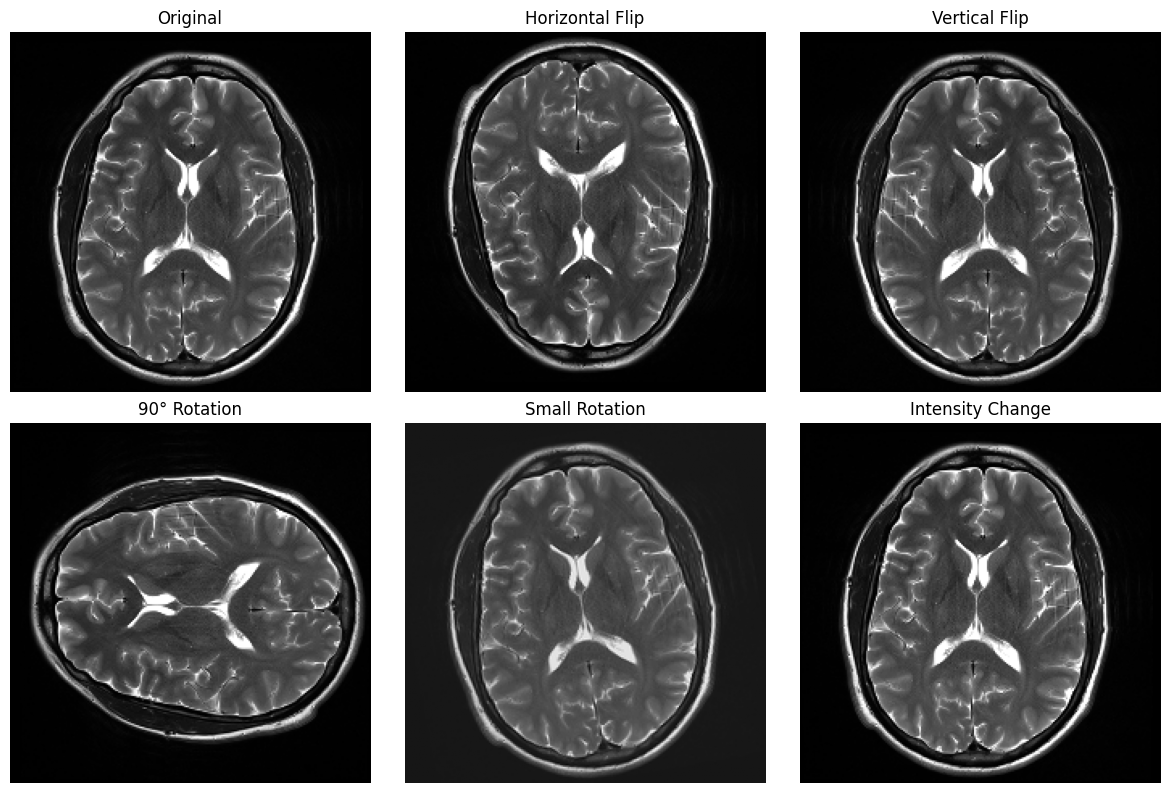

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

images = [
    image,
    flip_horizontal,
    flip_vertical,
    rotate_90,
    rotate_small,
    intensity_change
]

titles = [
    "Original",
    "Horizontal Flip",
    "Vertical Flip",
    "90° Rotation",
    "Small Rotation",
    "Intensity Change"
]

for ax, img, title in zip(axes.ravel(), images, titles):
    ax.imshow(img.T, cmap="gray",origin='lower')
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

Original: (224, 224)
Random crop: (64, 64)


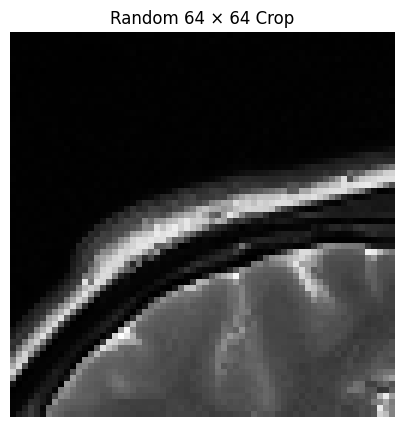

In [27]:
H, W = image.shape
crop_size = 64

i = np.random.randint(0, H - crop_size + 1)
j = np.random.randint(0, W - crop_size + 1)

random_crop = image[
    i:i + crop_size,
    j:j + crop_size
]

print("Original:", image.shape)
print("Random crop:", random_crop.shape)

plt.figure(figsize=(5, 5))
plt.imshow(random_crop, cmap="gray")
plt.title("Random 64 × 64 Crop")
plt.axis("off")
plt.show()

  ## Think About It

  Try changing:

  - rotation angle: 5°, 10°, 20°
  - intensity multiplier: 0.9, 1.1, 1.2
  - crop size: 32, 64, 96

  Observe what changes.

  ### Question

  Which augmentations would you use for this MRI?

  Which might be anatomically inappropriate?

  **Key lesson:**  
  An augmentation is useful only if the transformed image still represents a valid example for the imaging task.

  # Module 5: The denoising problem

  A noisy MRI can be written conceptually as:

  \[
  y = x + n
  \]

  where:

  - \(x\) = underlying clean image
  - \(n\) = noise
  - \(y\) = observed noisy image

  The goal is:

  \[
  f_	heta(y) pprox x
  \]

  In supervised learning, the network normally needs \(x\) as a training target.

  Today we will first understand that setup, then remove the clean target in Notebook 1.2.


## 5.1 Add controlled synthetic noise

For Experiment A, the original HF image remains available as an **evaluation/reference image**.

The noisy image is generated only to teach the denoising problem.


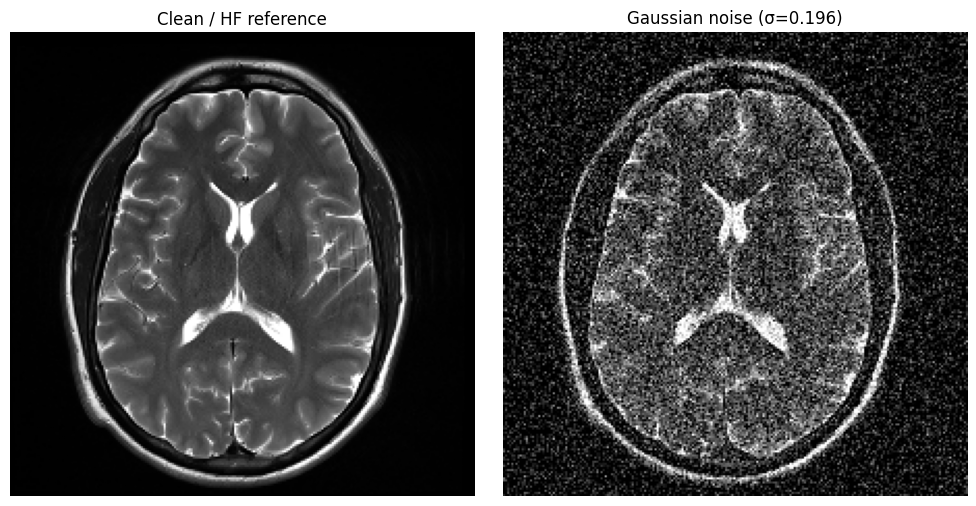

In [28]:
# ============================================================
# NOISE SETTINGS
# ============================================================

noise_type = 'gauss'     # 'gauss' or 'poiss'
noise_level = 50         # Gaussian: pixel-level sigma (0-255)
                         # Poisson: noise scaling parameter


# ============================================================
# NOISE FUNCTION
# ============================================================

def add_noise(x, noise_type='gauss', noise_level=25):

    # NumPy -> PyTorch
    if isinstance(x, np.ndarray):
        x = torch.from_numpy(x.astype(np.float32))

    if noise_type == 'gauss':

        # Convert 0-255 noise level to normalized 0-1 scale
        sigma = noise_level / 255.0

        noise = torch.normal(
            mean=0.0,
            std=sigma,
            size=x.shape
        )

        noisy = x + noise

        # Keep image in [0, 1]
        noisy = torch.clamp(noisy, 0, 1)

    elif noise_type == 'poiss':

        noisy = torch.poisson(noise_level * x) / noise_level

        # Keep image in [0, 1]
        noisy = torch.clamp(noisy, 0, 1)

    else:
        raise ValueError("noise_type must be 'gauss' or 'poiss'")

    return noisy


# ============================================================
# ADD NOISE
# ============================================================

noisy_img = add_noise(
    image,
    noise_type=noise_type,
    noise_level=noise_level
)

# Convert back to NumPy for plotting
noisy_np = noisy_img.numpy()


# ============================================================
# DISPLAY
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(
    image.T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)

ax[0].set_title("Clean / HF reference")

ax[1].imshow(
    noisy_np.T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)

if noise_type == 'gauss':
    sigma = noise_level / 255
    ax[1].set_title(f"Gaussian noise (σ={sigma:.3f})")
else:
    ax[1].set_title(f"Poisson noise (level={noise_level})")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()


# Experiment above with different noise levels and noise type

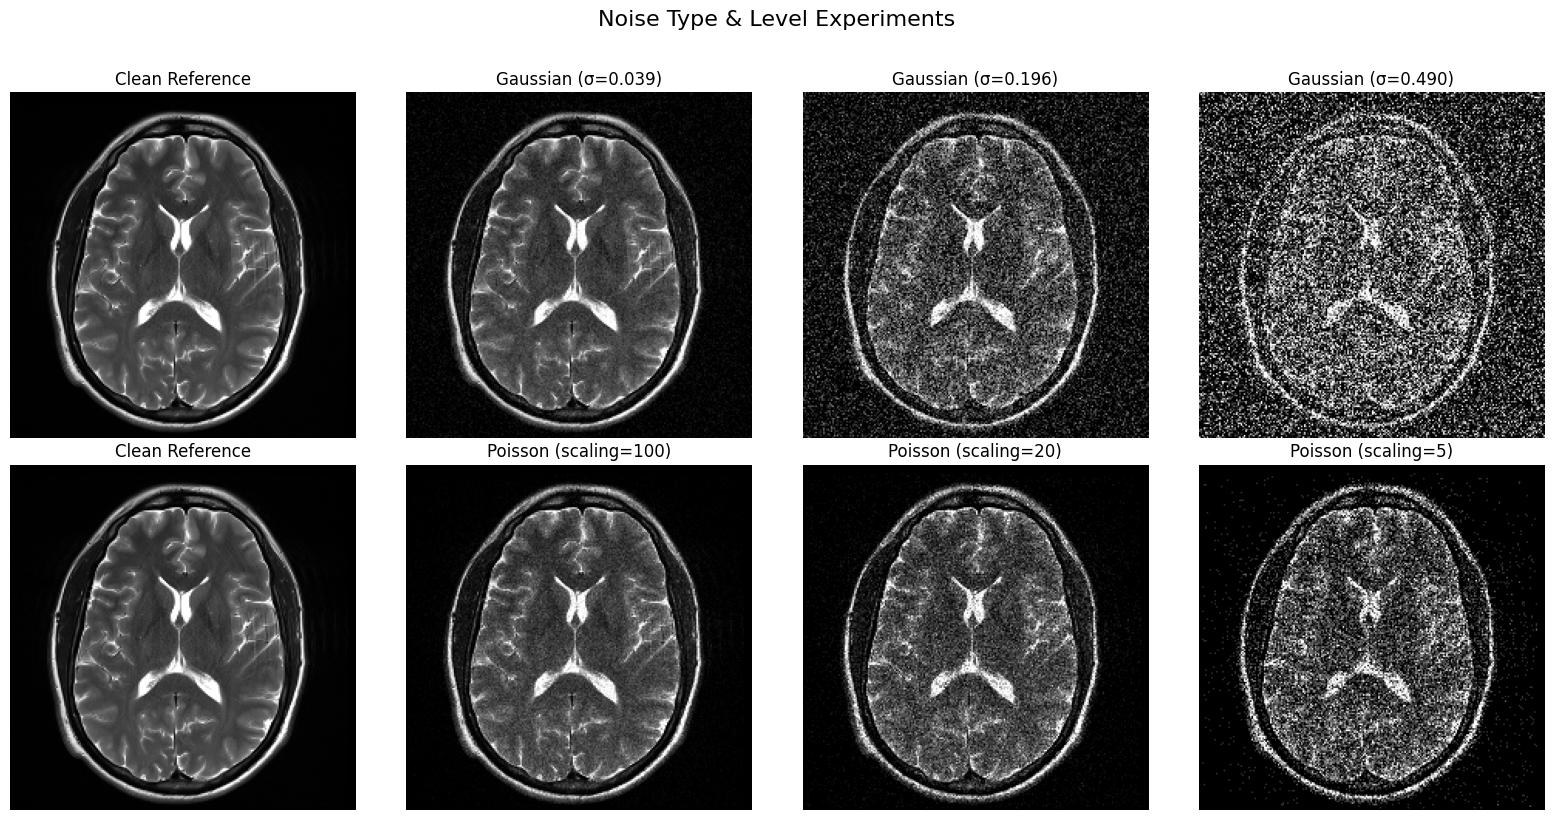

In [29]:
# ============================================================
# NOISE FUNCTION (Unchanged)
# ============================================================
def add_noise(x, noise_type='gauss', noise_level=25):
    if isinstance(x, np.ndarray):
        x = torch.from_numpy(x.astype(np.float32))

    if noise_type == 'gauss':
        sigma = noise_level / 255.0
        noise = torch.normal(mean=0.0, std=sigma, size=x.shape)
        noisy = x + noise
        noisy = torch.clamp(noisy, 0, 1)

    elif noise_type == 'poiss':
        noisy = torch.poisson(noise_level * x) / noise_level
        noisy = torch.clamp(noisy, 0, 1)

    else:
        raise ValueError("noise_type must be 'gauss' or 'poiss'")

    return noisy

# ============================================================
# EXPERIMENT PARAMETERS
# ============================================================
# Gaussian: Higher number = more noise (larger standard deviation)
gauss_levels = [10, 50, 125]

# Poisson: LOWER number = MORE noise
poiss_levels = [100, 20, 5]

# ============================================================
# RUN & DISPLAY EXPERIMENT
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row in range(2):
    axes[row, 0].imshow(image.T, cmap="gray", origin="lower", vmin=0, vmax=1)
    axes[row, 0].set_title("Clean Reference")

# Gaussian Noise Sweep (Top Row)
for i, level in enumerate(gauss_levels):
    noisy_np = add_noise(image, noise_type='gauss', noise_level=level).numpy()

    ax = axes[0, i + 1]
    ax.imshow(noisy_np.T, cmap="gray", origin="lower", vmin=0, vmax=1)
    ax.set_title(f"Gaussian (σ={level/255:.3f})")

# Poisson Noise Sweep (Bottom Row)
for i, level in enumerate(poiss_levels):
    noisy_np = add_noise(image, noise_type='poiss', noise_level=level).numpy()

    ax = axes[1, i + 1]
    ax.imshow(noisy_np.T, cmap="gray", origin="lower", vmin=0, vmax=1)
    ax.set_title(f"Poisson (scaling={level})")

for ax in axes.flatten():
    ax.axis("off")

plt.suptitle("Noise Type & Level Experiments", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

  ## From an image to a tensor

  A 2D CNN expects:

  \[
  B	imes C	imes H	imes W
  \]

  For one grayscale MRI slice:

  - `B = 1`: one image
  - `C = 1`: one MRI channel
  - `H, W`: spatial dimensions


In [30]:
noisy = torch.from_numpy(noisy_np).float()[None, None].to(device)
clean = torch.from_numpy(image).float()[None, None].to(device)

print("Tensor shape:", noisy.shape)

Tensor shape: torch.Size([1, 1, 224, 224])


# Module 6 — Understand Convolution

## What does a convolution actually do?

Before building a CNN, let's understand the basic operation. Do basic convolution peration on the notebook.

Consider this small image:

```text
1  2  3
4  5  6
7  8  9



In [31]:

### Code cell — manually calculate one convolution


import numpy as np

image_small = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
], dtype=np.float32)

kernel = np.array([
    [1,  0],
    [0, -1]
], dtype=np.float32)

# Take the top-left 2 × 2 region
region = image_small[0:2, 0:2]

# Element-wise multiplication
multiplication = region * kernel

# Sum
feature_value = multiplication.sum()

print("Image region:")
print(region)

print("\nKernel:")
print(kernel)

print("\nElement-wise multiplication:")
print(multiplication)

print("\nFeature value:")
print(feature_value)

Image region:
[[1. 2.]
 [4. 5.]]

Kernel:
[[ 1.  0.]
 [ 0. -1.]]

Element-wise multiplication:
[[ 1.  0.]
 [ 0. -5.]]

Feature value:
-4.0


    Explain the calculation
    Image region        Kernel

    1  2                1   0
    4  5                0  -1

    Element-wise multiplication:

    1×1   2×0
    4×0   5×(-1)

    Therefore:

    1 + 0 + 0 - 5 = -4

    So the first feature value is:

    −4

# let the kernel slide

In [32]:
output = []

for i in range(image_small.shape[0] - kernel.shape[0] + 1):
    row = []

    for j in range(image_small.shape[1] - kernel.shape[1] + 1):

        region = image_small[
            i:i+2,
            j:j+2
        ]

        value = np.sum(region * kernel)
        row.append(value)

    output.append(row)

output = np.array(output)

print("Feature map:")
print(output)

Feature map:
[[-4. -4.]
 [-4. -4.]]


## Think About It

Change the kernel to:

```text
1   1
1   1

    Key idea

    A convolution takes:

    local image information + kernel

    and produces:

    a feature value.

    A CNN uses many learnable kernels to automatically discover useful image features.

    ➡️ Next: We will replace our manually chosen kernel with a learnable CNN convolution layer.

  ## Module 7: A very small CNN

  We deliberately start small.

  A CNN learns filters that transform the noisy image into an output image.

  Here we use **residual learning**:

  \[
  \hat n = r_	heta(y)
  \]

  and reconstruct:

  \[
  \hat x = y-\hat n
  \]

  This is useful for denoising because the network can focus on learning the unwanted residual rather than reproducing the whole anatomy.


In [33]:
import torch
import torch.nn as nn
from torchinfo import summary

class network(nn.Module):
    def __init__(self, n_chan, chan_embed=48):
        super(network, self).__init__()

        self.act = nn.LeakyReLU(
            negative_slope=0.2,
            inplace=True
        )

        # Input → feature representation
        self.conv1 = nn.Conv2d(
            n_chan,
            chan_embed,
            kernel_size=3,
            padding=1
        )

        # Feature → feature
        self.conv2 = nn.Conv2d(
            chan_embed,
            chan_embed,
            kernel_size=3,
            padding=1
        )

        # Feature → output image
        self.conv3 = nn.Conv2d(
            chan_embed,
            n_chan,
            kernel_size=1
        )

    def forward(self, x):

        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.conv3(x)

        return x

# Instantiate the model (assuming 1 input channel for a standard magnitude image)
model = network(n_chan=1)

# Print a summary assuming a batch size of 1, and an image size of 256x256
summary(model, input_size=(1, 1, 256, 256))

Layer (type:depth-idx)                   Output Shape              Param #
network                                  [1, 1, 256, 256]          --
├─Conv2d: 1-1                            [1, 48, 256, 256]         480
├─LeakyReLU: 1-2                         [1, 48, 256, 256]         --
├─Conv2d: 1-3                            [1, 48, 256, 256]         20,784
├─LeakyReLU: 1-4                         [1, 48, 256, 256]         --
├─Conv2d: 1-5                            [1, 1, 256, 256]          49
Total params: 21,313
Trainable params: 21,313
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 1.40
Input size (MB): 0.26
Forward/backward pass size (MB): 50.86
Params size (MB): 0.09
Estimated Total Size (MB): 51.20

[ Input Image ] Shape: (B, n_chan, H, W)

⬇

Conv1 + LeakyReLU

3x3 kernels, Padding=1 (Keeps H and W the same)

Expands channels from 'n_chan' to 48

⬇

[ Feature Map ] Shape: (B, 48, H, W)

⬇

Conv2 + LeakyReLU

3x3 kernels, Padding=1

Processes the 48 hidden channels

⬇

[ Feature Map ] Shape: (B, 48, H, W)

⬇

Conv3 (No Activ.)

1x1 kernel (Acts as a pixel-wise linear blender)

Compresses 48 channels back down to 'n_chan'

⬇

[ Final Image ] Shape: (B, n_chan, H, W)

In [34]:
# For a grayscale MRI image
n_chan = 1

model = network(
    n_chan=n_chan,
    chan_embed=48
)

model = model.to(device)

print(model)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)


network(
  (act): LeakyReLU(negative_slope=0.2, inplace=True)
  (conv1): Conv2d(1, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(48, 1, kernel_size=(1, 1), stride=(1, 1))
)
Trainable parameters: 21313


# Explore conversion 2D to 3D network.

  # Module 8 — Activation Functions

  Activation functions introduce **non-linearity** into a neural network.

  Without an activation function, stacking convolution layers would still behave like a linear transformation. Activation functions allow the CNN to learn more complex patterns such as edges, textures, and anatomical structures.

  We will compare four common activation functions:

  1. **ReLU**
  2. **Leaky ReLU**
  3. **Sigmoid**
  4. **Tanh**

  For image denoising, activation functions are mainly used in the **hidden layers**.

  Our CNN will use **Leaky ReLU** in the hidden layers.

  ### Important idea

  For continuous image prediction, the final convolution layer is usually **linear**.

  So our denoising CNN follows:

      Input
        ↓
      Conv
        ↓
      Leaky ReLU
        ↓
      Conv
        ↓
      Leaky ReLU
        ↓
      Conv
        ↓
      Output

  The final layer does not need Sigmoid because we are predicting continuous MRI intensity values.

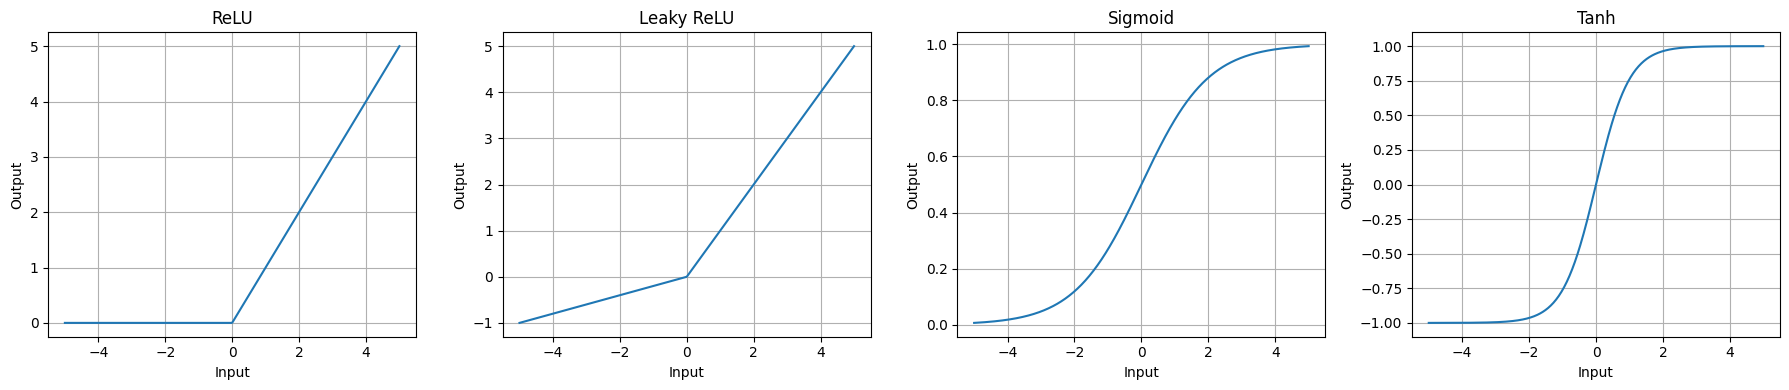

In [35]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 500)

# Activation functions
relu = np.maximum(0, x)

leaky_relu = np.where(x > 0, x, 0.2 * x)

sigmoid = 1 / (1 + np.exp(-x))

tanh = np.tanh(x)

fig, ax = plt.subplots(1, 4, figsize=(18, 4))

ax[0].plot(x, relu)
ax[0].set_title("ReLU")
ax[0].set_xlabel("Input")
ax[0].set_ylabel("Output")
ax[0].grid(True)

ax[1].plot(x, leaky_relu)
ax[1].set_title("Leaky ReLU")
ax[1].set_xlabel("Input")
ax[1].set_ylabel("Output")
ax[1].grid(True)

ax[2].plot(x, sigmoid)
ax[2].set_title("Sigmoid")
ax[2].set_xlabel("Input")
ax[2].set_ylabel("Output")
ax[2].grid(True)

ax[3].plot(x, tanh)
ax[3].set_title("Tanh")
ax[3].set_xlabel("Input")
ax[3].set_ylabel("Output")
ax[3].grid(True)

plt.tight_layout()
plt.show()


## What do they do?

```text
ReLU
negative input → 0
positive input → unchanged

ReLU introduces a non-linearity while keeping positive values.

Sigmoid
any input → value between 0 and 1

This is useful when the output represents a probability or needs to be restricted to [0, 1].

Tanh
any input → value between -1 and 1

It is another nonlinear activation, but it can saturate for large positive or negative inputs.

    Why use ReLU inside a denoising CNN?

    A simple denoising network can look like:

    Input
      ↓
    Conv
      ↓
    ReLU
      ↓
    Conv
      ↓
    ReLU
      ↓
    Conv
      ↓
    Output

    The ReLU layers allow the CNN to learn nonlinear relationships between local image patterns.

    Why not use Sigmoid on the final layer?

    Our MRI target is normalized to [0, 1], but the CNN's final convolution is performing continuous image regression.

    We therefore commonly leave the final layer linear:

    Conv → ReLU → Conv → ReLU → Conv → Output
                                          ↑
                                  linear output

    The final layer is allowed to produce the values needed to represent the predicted image rather than forcing the output through a sigmoid.

    If necessary, the predicted image can be clipped to [0, 1] for visualization or evaluation.

    Important distinction:

    ReLU is useful for hidden feature layers.
    The final layer of an image-regression network does not necessarily need an activation function.


  ### 🧠 Short student exercise

  ```markdown
  ## Think About It

  Look at the three plots.

  1. What happens to a negative value after ReLU?
  It becomes exactly zero.

  2. What is the output range of sigmoid?
  Between 0 and 1.

  3. What is the output range of tanh?
  Between -1 and 1.

  4. Why might a sigmoid be restrictive for the final layer of an image-regression network?
  Sigmoid heavily dampens gradients at its extremes (vanishing gradients). Even if your target image is perfectly normalized to a [0, 1] range, the network will struggle to output pure black (0) or pure white (1) pixels because the learning signal stalls as it approaches those boundaries. Additionally, if your target image contains values outside the [0, 1] range (such as raw, unscaled intensity values), sigmoid physically prevents the network from ever reaching them.
  
  ### Key idea

  **Activation functions control how information flows through the network.**

  For our denoising CNN:

  **Conv → ReLU → Conv → ReLU → Conv → image**

# Module 9 — Pooling and Upsampling

    ## Changing Spatial Resolution

    CNNs can change the spatial size of an image.

    Two important operations are:

    - **Pooling** → reduces spatial resolution
    - **Upsampling** → increases spatial resolution

    These ideas are important for understanding architectures such as **U-Net**.

In [36]:
import numpy as np

small_image = np.array([
    [4, 2],
    [1, 3]
])

max_value = np.max(small_image)

print("Input:")
print(small_image)

print("\nAfter max pooling:")
print(max_value)

Input:
[[4 2]
 [1 3]]

After max pooling:
4


Original: torch.Size([1, 1, 224, 224])
After max pooling: torch.Size([1, 1, 112, 112])


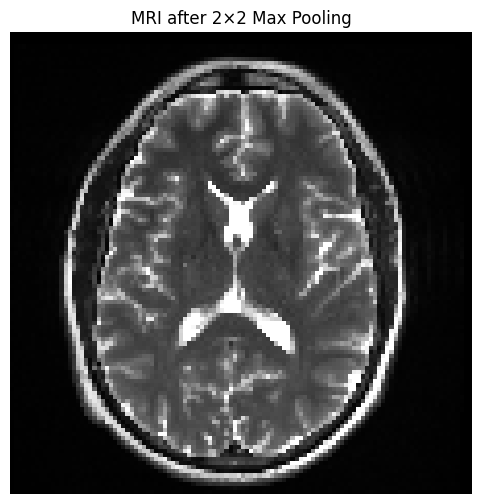

In [37]:
### Code cell — visualize pooling on an MRI


import torch
import torch.nn.functional as F

image_tensor = torch.from_numpy(
    image_minmax.astype(np.float32)
).unsqueeze(0).unsqueeze(0)   # B × C × H × W

pooled = F.max_pool2d(
    image_tensor,
    kernel_size=2
)

print("Original:", image_tensor.shape)
print("After max pooling:", pooled.shape)

plt.figure(figsize=(6, 6))
plt.imshow(
    pooled[0, 0].numpy().T,
    cmap="gray",
    origin="lower"
)
plt.title("MRI after 2×2 Max Pooling")
plt.axis("off")
plt.show()

## Upsampling

Pooling reduces spatial size.

Upsampling does the opposite:

```text
16 × 16
   ↓
32 × 32
   ↓
64 × 64

  Two common approaches are:

    Nearest-neighbor interpolation — copies nearby values
    Bilinear interpolation — estimates values using neighboring pixels

Original MRI tensor:       torch.Size([1, 1, 224, 224])
After max pooling:         torch.Size([1, 1, 112, 112])
Nearest-neighbor output:   torch.Size([1, 1, 224, 224])
Bilinear output:           torch.Size([1, 1, 224, 224])


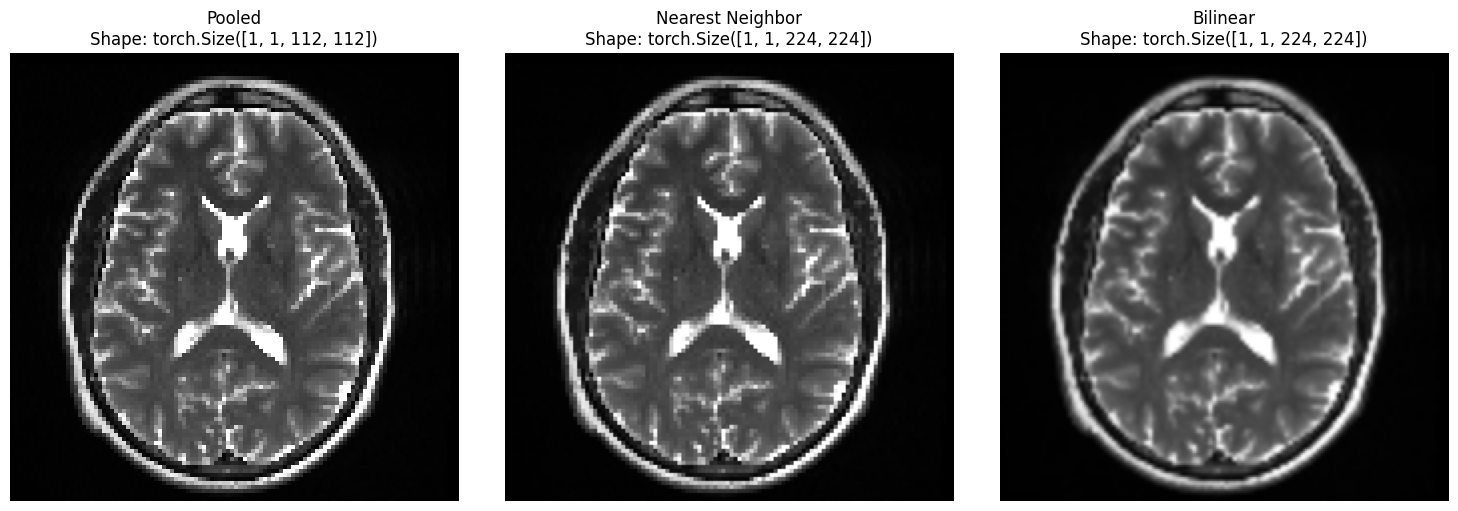

In [38]:
upsampled_nearest = F.interpolate(
    pooled,
    size=image_tensor.shape[-2:],
    mode="nearest"
)

upsampled_bilinear = F.interpolate(
    pooled,
    size=image_tensor.shape[-2:],
    mode="bilinear",
    align_corners=False
)

# Print tensor shapes
print("Original MRI tensor:      ", image_tensor.shape)
print("After max pooling:        ", pooled.shape)
print("Nearest-neighbor output:  ", upsampled_nearest.shape)
print("Bilinear output:          ", upsampled_bilinear.shape)


fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(
    pooled[0, 0].numpy().T,
    cmap="gray",
    origin="lower"
)
ax[0].set_title(f"Pooled\nShape: {pooled.shape}")

ax[1].imshow(
    upsampled_nearest[0, 0].numpy().T,
    cmap="gray",
    origin="lower"
)
ax[1].set_title(f"Nearest Neighbor\nShape: {upsampled_nearest.shape}")

ax[2].imshow(
    upsampled_bilinear[0, 0].numpy().T,
    cmap="gray",
    origin="lower"
)
ax[2].set_title(f"Bilinear\nShape: {upsampled_bilinear.shape}")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

# Module 10 — Forward Pass and Network Output

Now we give the CNN the **entire noisy MRI slice**.

```text
Noisy MRI
   ↓
  CNN
   ↓
Predicted clean MRI

    The CNN performs an image-to-image transformation.

    The input is:

    B × C × H × W

    and because our CNN does not use pooling or upsampling, the output has the same shape:

    B × C × H × W

    At this point, the network is untrained.

    Its convolution kernels were randomly initialized, so the prediction will usually look poor.

    That is good.

    "This is what a randomly initialized neural network looks like before learning."

    We will inspect the network output before training so that we can later see how much it improves.

In [39]:
# Clean MRI
clean_image = torch.from_numpy(
    image_minmax.astype(np.float32)
)

# Add Gaussian noise
noisy_image = add_noise(
    clean_image,
    noise_type="gauss",
    noise_level=50
)

# Add batch and channel dimensions
# H × W → B × C × H × W
noisy_input = noisy_image.unsqueeze(0).unsqueeze(0)

# Create CNN
model = network(
    n_chan=1,
    chan_embed=48
)

# Forward pass
prediction = model(noisy_input)

# Create target with the same dimensions
target = clean_image.unsqueeze(0).unsqueeze(0)

print("Prediction shape:", prediction.shape)
print("Target shape:    ", target.shape)

print("Prediction min: ", prediction.min().item())
print("Prediction max: ", prediction.max().item())
print("Prediction mean:", prediction.mean().item())

print("Target min: ", target.min().item())
print("Target max: ", target.max().item())
print("Target mean:", target.mean().item())

Prediction shape: torch.Size([1, 1, 224, 224])
Target shape:     torch.Size([1, 1, 224, 224])
Prediction min:  -0.1187005415558815
Prediction max:  0.04552426561713219
Prediction mean: -0.04026589170098305
Target min:  0.0
Target max:  1.0
Target mean: 0.17348916828632355


    ## What happened inside the CNN?

    The entire MRI image passed through the network:*

    ```text
    Noisy MRI
    B × C × H × W
          ↓
      Conv 3×3
          ↓
    Leaky ReLU
          ↓
      Conv 3×3
          ↓
    Leaky ReLU
          ↓
      Conv 1×1
          ↓
    Predicted MRI
    B × C × H × W

    The network has produced a prediction for every pixel in the input image.

    However, the network has not learned denoising yet.

    So the output is not expected to look like the clean MRI.

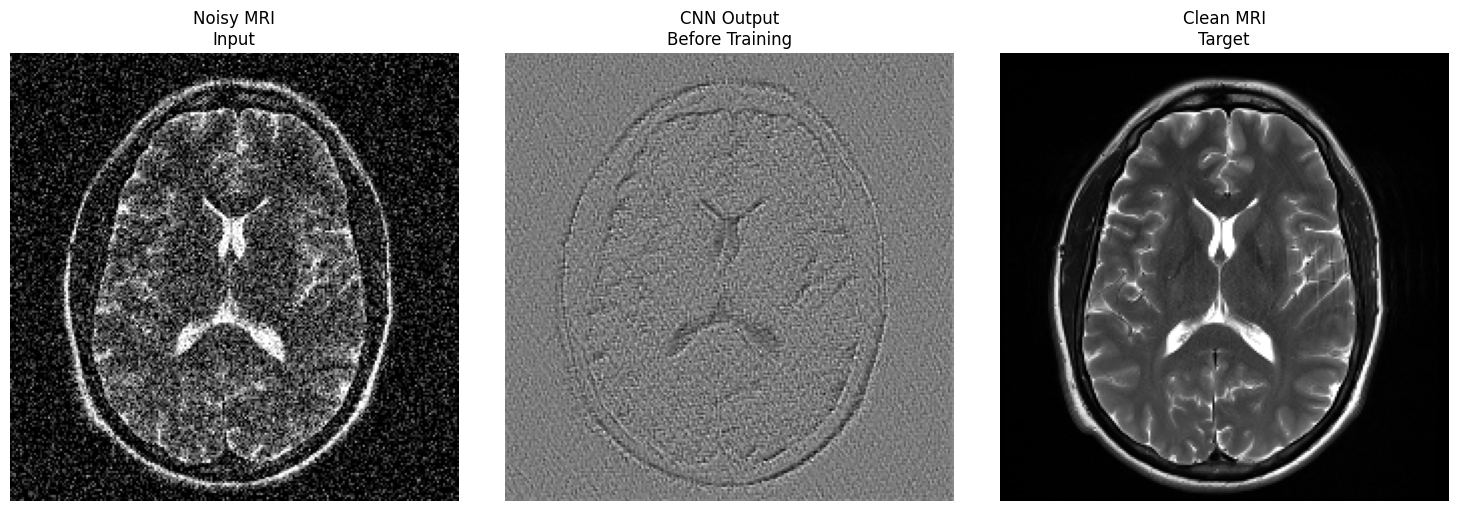

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Noisy input
axes[0].imshow(
    noisy_input[0, 0].detach().numpy().T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)
axes[0].set_title("Noisy MRI\nInput")

# Untrained CNN output
axes[1].imshow(
    prediction[0, 0].detach().numpy().T,
    cmap="gray",
    origin="lower",
)
axes[1].set_title("CNN Output\nBefore Training")

# Clean target
axes[2].imshow(
    target[0, 0].detach().numpy().T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)
axes[2].set_title("Clean MRI\nTarget")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Module 11 — Loss Functions

        The CNN has produced a prediction, but how do we know whether it is good?

        We compare:

        ```text
        Predicted clean MRI
                ↓
              Loss
                ↑
        Clean target

        The loss function converts the difference between prediction and target into a number.

        Small loss → prediction is close to the target
        Large loss → prediction is far from the target

        Today we will look at:

        MSE — Mean Squared Error
        MAE / L1 — Mean Absolute Error
        Smooth L1 / Huber Loss
        Perceptual Loss

        We will start training with MSE because it is simple and easy to understand.


        ---

        ## 11.1 MSE — Mean Squared Error


# Learn how to compute MSE.

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
noisy = noisy.to(device)
clean = clean.to(device)

model.eval() #switches from Training to Testing mode

with torch.no_grad():
    prediction = model(noisy)

mse = torch.nn.functional.mse_loss(prediction, clean)

print("MSE:", mse.item())

MSE: 0.09203793853521347


In [42]:
mse_loss = nn.MSELoss()
l1_loss = nn.L1Loss()
smooth_l1_loss = nn.SmoothL1Loss()

# Ensure the model is on the correct device
model = model.to(device)

with torch.no_grad():
    prediction = model(noisy) #When we are just trying to test the model and not trying to update its weights

print("MSE:", mse_loss(prediction, clean).item())
print("L1 :", l1_loss(prediction, clean).item())
print("Smooth L1:", smooth_l1_loss(prediction, clean).item())

MSE: 0.09203793853521347
L1 : 0.21431933343410492
Smooth L1: 0.045996177941560745


## Make the loss yourself
      
    Instead of hiding the loss inside PyTorch, calculate it explicitly.

    This helps you understand what the optimizer actually sees.


In [43]:
def manual_mse(pred, target):
    error = pred - target
    squared_error = error ** 2
    return squared_error.mean()

def manual_l1(pred, target):
    error = pred - target
    absolute_error = torch.abs(error)
    return absolute_error.mean()

# Ensure clean is on the correct device (GPU) for manual calculations
clean_on_device = clean.to(device)

print("Manual MSE:", manual_mse(prediction, clean_on_device).item())
print("Manual L1 :", manual_l1(prediction, clean_on_device).item())

Manual MSE: 0.09203793853521347
Manual L1 : 0.21431933343410492


# Module 12 — Evaluation Metrics

After a CNN produces a denoised MRI, we need to evaluate the result.

We will compare:

```text
Denoised MRI
     ↓
   Metric
     ↑
Clean MRI

    Main metrics
    MSE / MAE → How different are the pixel values?
    PSNR → How much reconstruction error is present?
    SSIM → How similar are local structures?
    LPIPS → How similar are learned image features?
    Edge / gradient preservation → Are important boundaries and details preserved?

    We will also briefly discuss FID, but we will not use it as a
    practical metric for this single-image MRI denoising experiment.

    Higher PSNR generally means the reconstructed image is
     closer to the reference in terms of pixel values.

  ## Quick Exercise

      If two denoised images have:

      - Image A: PSNR = 30 dB
      - Image B: PSNR = 25 dB

      Which image has the smaller reconstruction error?

      **Answer:** Image A.

  ## SSIM — Structural Similarity Index

        PSNR mainly asks:

        > "How close are the pixel values?"

        SSIM asks approximately:

        > "How similar are the local structures?"

        SSIM considers local image characteristics such as:

        - luminance
        - contrast
        - structural patterns

        SSIM is particularly useful for medical images because preserving anatomical structure is often more important than matching every individual pixel exactly.

        Typical interpretation:

        ```text
        SSIM ≈ 1
            ↓
        Very similar structure

        Lower SSIM
            ↓
        Greater structural difference

    SSIM is generally reported between 0 and 1 for common image-comparison
    settings, although its exact range depends on the implementation.

In [44]:
# ============================================================
# Code cell — Calculate SSIM
# ============================================================

from skimage.metrics import structural_similarity as ssim

# Re-convert PyTorch tensors to NumPy, ensuring they are 2D arrays (H x W)
# The `squeeze()` method removes all dimensions of size 1.
clean_np_corrected = clean.squeeze().detach().cpu().numpy()
prediction_np_corrected = prediction.squeeze().detach().cpu().numpy()

ssim_value = ssim(
    clean_np_corrected,
    prediction_np_corrected,
    data_range=1.0
)

print(f"SSIM: {ssim_value:.4f}")

SSIM: -0.1300


  ## PSNR vs SSIM

      Two images can have similar pixel-wise error but differ in how well they preserve structures.

      ```text
      PSNR
      ↓
      Pixel-level similarity

      SSIM
      ↓
      Local structural similarity

## LPIPS — Learned Perceptual Image Patch Similarity

    LPIPS is different from MSE, MAE, PSNR, and SSIM.

    Instead of comparing only individual pixel values, LPIPS compares **learned feature representations**.

    Conceptually:

    ```text
    Image
      ↓
    Feature Network
      ↓
    Learned Features
      ↓
    Feature Difference
      ↓
    LPIPS

    A smaller LPIPS value generally means the images are more perceptually similar according to the chosen learned feature network.

    Why is this interesting?

    Two images can have different pixel values but still contain similar visual structures.

    LPIPS attempts to capture this type of perceptual similarity.

    However, LPIPS was developed primarily around natural-image feature representations. Its interpretation for MRI should therefore be made carefully rather than treating it as a definitive clinical metric.

# Putting the metrics together

    ### Markdown cell

    ```markdown
    ## Which metric answers which question?

    | Metric | Main question | Better direction |
    |---|---|---|
    | MSE | How large is the squared pixel error? | Lower |
    | MAE | How large is the absolute pixel error? | Lower |
    | PSNR | How good is pixel-level reconstruction? | Higher |
    | SSIM | How well is local structure preserved? | Higher |
    | LPIPS | How similar are learned image features? | Lower |
    | Edge/Gradient | Are edges and boundaries preserved? | Lower difference |
    | FID | Are real and generated image distributions similar? | Lower |

    ### Important lesson

    No single metric completely describes MRI denoising quality.

    A good evaluation should combine:

    **Numerical metrics + structural metrics + visual inspection.**

  ## Quick Exercise — Which metric would you use?

      Imagine a denoised MRI has:

      - Excellent PSNR
      - Good MSE
      - Lower SSIM
      - Very smooth appearance

      What might this tell you?

      **Think:** A model can achieve good pixel-wise numbers while removing
      fine anatomical structures.

      This is why we evaluate the image using multiple complementary measures.

# Module 13: Optimization

    The CNN initially contains randomly initialized parameters.

    During training, we want to find parameter values that minimize the loss.

        The learning process is:

            Noisy MRI
                ↓
            CNN
                ↓
            Prediction
                ↓
            Loss computation with the target
                ↓
            Backpropagation
                ↓
            Gradients
                ↓
            Optimizer
                ↓
            Updated CNN parameters
                ↓
            Repeat

    ### What is an optimizer?

    An optimizer determines how the CNN parameters should be changed using the gradients calculated during backpropagation.

    Two commonly used optimizers are:

        - **Adam (Adaptive Moment Estimation)** — adaptive learning-rate optimization;
        - **SGD (Stochastic Gradient Descent optimizer)** — updates parameters using gradients and a learning rate

    The **learning rate** controls how large each parameter update is.

    Too large → training can become unstable.

    Too small → training can become very slow.

In [45]:
import torch.optim as optim

optimizer_adam = optim.Adam(
    model.parameters(),
    lr=1e-3
)

print(optimizer_adam)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


    Adam
    ↓
    uses gradients
    ↓
    adapts parameter updates
    ↓
    updates CNN weights

## SGD

In [46]:
optimizer_sgd = optim.SGD(
    model.parameters(),
    lr=1e-2,
    momentum=0.9
)

print(optimizer_sgd)

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)


    Small comparison
        | Optimizer | Main idea | Typical behavior |
        |---|---|---|
        | Adam | Adaptive parameter updates | Usually fast and easy to train |
        | SGD | Gradient-based updates | Simple and can generalize well |

  ## Quick Exercise

    Try changing the learning rate:

    - `1e-2`
    - `1e-3`
    - `1e-4`

    Think about:

    1. Which learning rate makes the loss decrease faster?
    2. What happens if the learning rate is too large?
    3. What happens if it is too small?

    For the main MRI denoising experiment, we will use **Adam with learning rate = 1e-3**.

  # Module 14: Then transition into your training loop-->One complete training step


  Recap: #
  
  Forward pass -
  
    **Forward → Loss
    
    prediction = model(noisy_input)

    

  The complete learning loop is:

      **Forward → Loss → Backward → Optimizer step**


In [47]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)

optimizer.zero_grad()
#forward-pass
prediction = model(noisy)
#Compute loss
loss = F.mse_loss(prediction, clean)
#backpropogation
loss.backward()

optimizer.step()

print("One-step loss:", loss.item())


One-step loss: 0.09203793853521347


    Evaluation after one step

DENOISING EVALUATION
PSNR - Noisy:       15.28 dB
PSNR - Denoised:    13.22 dB
PSNR Improvement:   -2.06 dB
------------------------------------------------------------
SSIM - Noisy:       0.4019
SSIM - Denoised:    0.2632
SSIM Improvement:   -0.1386


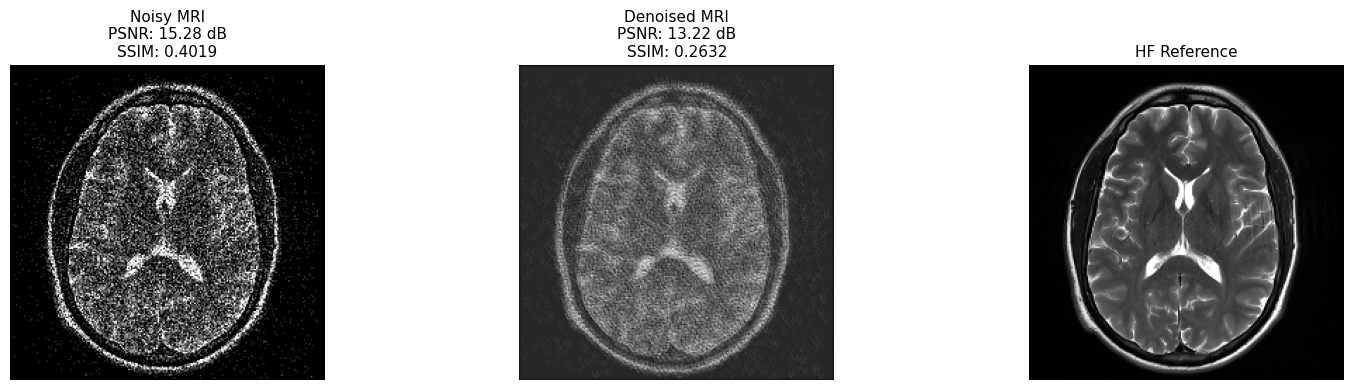

In [48]:
# ============================================================
# 📊 EVALUATE DENOISING
# PSNR + SSIM + Visual Comparison
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)


# ------------------------------------------------------------
# 1. Run the trained model
# ------------------------------------------------------------

model.eval()

with torch.no_grad():
    denoised = model(noisy)


# ------------------------------------------------------------
# 2. Convert tensors to NumPy
# ------------------------------------------------------------

noisy_np = noisy.squeeze().detach().cpu().numpy()
# residual_np = residual.squeeze().detach().cpu().numpy()
denoised_np = denoised.squeeze().detach().cpu().numpy()
clean_np = clean.squeeze().detach().cpu().numpy()


# ------------------------------------------------------------
# 3. Define intensity range
# ------------------------------------------------------------

data_range = clean_np.max() - clean_np.min()


# ------------------------------------------------------------
# 4. Calculate PSNR
# ------------------------------------------------------------

psnr_noisy = peak_signal_noise_ratio(
    clean_np,
    noisy_np,
    data_range=data_range
)

psnr_denoised = peak_signal_noise_ratio(
    clean_np,
    denoised_np,
    data_range=data_range
)

psnr_improvement = psnr_denoised - psnr_noisy


# ------------------------------------------------------------
# 5. Calculate SSIM
# ------------------------------------------------------------

ssim_noisy = structural_similarity(
    clean_np,
    noisy_np,
    data_range=data_range
)

ssim_denoised = structural_similarity(
    clean_np,
    denoised_np,
    data_range=data_range
)

ssim_improvement = ssim_denoised - ssim_noisy


# ------------------------------------------------------------
# 6. Print quantitative results
# ------------------------------------------------------------

print("=" * 60)
print("DENOISING EVALUATION")
print("=" * 60)

print(f"PSNR - Noisy:       {psnr_noisy:.2f} dB")
print(f"PSNR - Denoised:    {psnr_denoised:.2f} dB")
print(f"PSNR Improvement:   {psnr_improvement:+.2f} dB")

print("-" * 60)

print(f"SSIM - Noisy:       {ssim_noisy:.4f}")
print(f"SSIM - Denoised:    {ssim_denoised:.4f}")
print(f"SSIM Improvement:   {ssim_improvement:+.4f}")

print("=" * 60)


# ------------------------------------------------------------
# 7. Visual comparison
# ------------------------------------------------------------

fig, ax = plt.subplots(1, 3, figsize=(16, 4))


# Noisy MRI
ax[0].imshow(noisy_np.T, cmap="gray", origin = 'lower')
ax[0].set_title(
    f"Noisy MRI\n"
    f"PSNR: {psnr_noisy:.2f} dB\n"
    f"SSIM: {ssim_noisy:.4f}",
    fontsize=11
)



# Denoised MRI
ax[1].imshow(denoised_np.T, cmap="gray",origin = 'lower')
ax[1].set_title(
    f"Denoised MRI\n"
    f"PSNR: {psnr_denoised:.2f} dB\n"
    f"SSIM: {ssim_denoised:.4f}",
    fontsize=11
)


# HF reference
ax[2].imshow(clean_np.T, cmap="gray",origin = 'lower')
ax[2].set_title(
    "HF Reference",
    fontsize=11
)


# Remove axes
for a in ax:
    a.axis("off")


plt.tight_layout()
plt.show()

## Training step for n steps



In [49]:
import torch.optim as optim
import torch.nn.functional as F

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

for step in range(5000):

    # 1. Clear old gradients
    optimizer.zero_grad()

    # 2. Forward pass
    prediction = model(noisy)

    # 3. Calculate loss --> with supervised manner
    loss = F.mse_loss(prediction, clean)

    # 4. Backpropagation
    loss.backward()

    # 5. Update network parameters
    optimizer.step()

    print(f"Step {step + 1:02d} | Loss: {loss.item():.6f}")

Step 01 | Loss: 0.047631
Step 02 | Loss: 0.026472
Step 03 | Loss: 0.023076
Step 04 | Loss: 0.023710
Step 05 | Loss: 0.020179
Step 06 | Loss: 0.014620
Step 07 | Loss: 0.010384
Step 08 | Loss: 0.008505
Step 09 | Loss: 0.008600
Step 10 | Loss: 0.009170
Step 11 | Loss: 0.009090
Step 12 | Loss: 0.008329
Step 13 | Loss: 0.007706
Step 14 | Loss: 0.007940
Step 15 | Loss: 0.008758
Step 16 | Loss: 0.009231
Step 17 | Loss: 0.008923
Step 18 | Loss: 0.008155
Step 19 | Loss: 0.007465
Step 20 | Loss: 0.007146
Step 21 | Loss: 0.007116
Step 22 | Loss: 0.007116
Step 23 | Loss: 0.006973
Step 24 | Loss: 0.006702
Step 25 | Loss: 0.006442
Step 26 | Loss: 0.006327
Step 27 | Loss: 0.006389
Step 28 | Loss: 0.006554
Step 29 | Loss: 0.006698
Step 30 | Loss: 0.006736
Step 31 | Loss: 0.006666
Step 32 | Loss: 0.006553
Step 33 | Loss: 0.006466
Step 34 | Loss: 0.006438
Step 35 | Loss: 0.006445
Step 36 | Loss: 0.006441
Step 37 | Loss: 0.006390
Step 38 | Loss: 0.006299
Step 39 | Loss: 0.006205
Step 40 | Loss: 0.006151


# 📊 Evaluate Denoising: PSNR Comparison and Visualization

In this cell, we compare the noisy MRI and denoised MRI with the clean
high-field (HF) reference image.

We use **PSNR (Peak Signal-to-Noise Ratio)** as a quantitative measure
of image similarity.

### What are we comparing?

- **Noisy MRI vs HF reference** → baseline quality
- **Denoised MRI vs HF reference** → after denoising
- **PSNR improvement** → effect of the denoising model

> Higher PSNR generally indicates greater similarity to the reference image.

⚠️ In the real low-field MRI experiment, the HF image is used only for
**evaluation**, not for training the zero-shot model.

DENOISING EVALUATION
PSNR - Noisy:       15.28 dB
PSNR - Denoised:    25.53 dB
PSNR Improvement:   +10.25 dB
------------------------------------------------------------
SSIM - Noisy:       0.4019
SSIM - Denoised:    0.8106
SSIM Improvement:   +0.4087


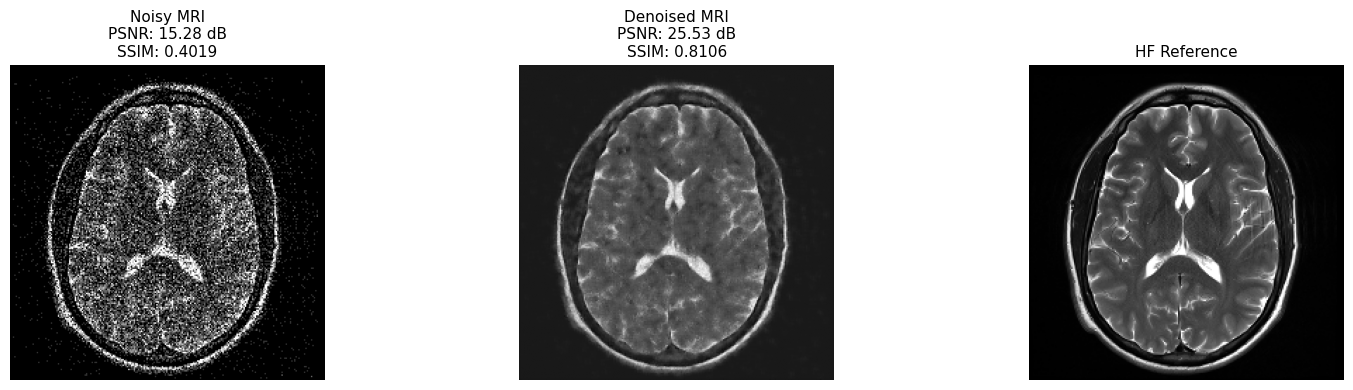

In [50]:
# ============================================================
# 📊 EVALUATE DENOISING
# PSNR + SSIM + Visual Comparison
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)


# ------------------------------------------------------------
# 1. Run the trained model
# ------------------------------------------------------------

model.eval()

with torch.no_grad():
    denoised = model(noisy)


# ------------------------------------------------------------
# 2. Convert tensors to NumPy
# ------------------------------------------------------------

noisy_np = noisy.squeeze().detach().cpu().numpy()
# residual_np = residual.squeeze().detach().cpu().numpy()
denoised_np = denoised.squeeze().detach().cpu().numpy()
clean_np = clean.squeeze().detach().cpu().numpy()


# ------------------------------------------------------------
# 3. Define intensity range
# ------------------------------------------------------------

data_range = clean_np.max() - clean_np.min()


# ------------------------------------------------------------
# 4. Calculate PSNR
# ------------------------------------------------------------

psnr_noisy = peak_signal_noise_ratio(
    clean_np,
    noisy_np,
    data_range=data_range
)

psnr_denoised = peak_signal_noise_ratio(
    clean_np,
    denoised_np,
    data_range=data_range
)

psnr_improvement = psnr_denoised - psnr_noisy


# ------------------------------------------------------------
# 5. Calculate SSIM
# ------------------------------------------------------------

ssim_noisy = structural_similarity(
    clean_np,
    noisy_np,
    data_range=data_range
)

ssim_denoised = structural_similarity(
    clean_np,
    denoised_np,
    data_range=data_range
)

ssim_improvement = ssim_denoised - ssim_noisy


# ------------------------------------------------------------
# 6. Print quantitative results
# ------------------------------------------------------------

print("=" * 60)
print("DENOISING EVALUATION")
print("=" * 60)

print(f"PSNR - Noisy:       {psnr_noisy:.2f} dB")
print(f"PSNR - Denoised:    {psnr_denoised:.2f} dB")
print(f"PSNR Improvement:   {psnr_improvement:+.2f} dB")

print("-" * 60)

print(f"SSIM - Noisy:       {ssim_noisy:.4f}")
print(f"SSIM - Denoised:    {ssim_denoised:.4f}")
print(f"SSIM Improvement:   {ssim_improvement:+.4f}")

print("=" * 60)


# ------------------------------------------------------------
# 7. Visual comparison
# ------------------------------------------------------------

fig, ax = plt.subplots(1, 3, figsize=(16, 4))


# Noisy MRI
ax[0].imshow(noisy_np.T, cmap="gray", origin = 'lower')
ax[0].set_title(
    f"Noisy MRI\n"
    f"PSNR: {psnr_noisy:.2f} dB\n"
    f"SSIM: {ssim_noisy:.4f}",
    fontsize=11
)


# Denoised MRI
ax[1].imshow(denoised_np.T, cmap="gray", origin = 'lower')
ax[1].set_title(
    f"Denoised MRI\n"
    f"PSNR: {psnr_denoised:.2f} dB\n"
    f"SSIM: {ssim_denoised:.4f}",
    fontsize=11
)


# HF reference
ax[2].imshow(clean_np.T, cmap="gray", origin = 'lower')
ax[2].set_title(
    "HF Reference",
    fontsize=11
)


# Remove axes
for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

# Apply model on the test example slice; --> other than 80


Processing slice 70:
New Noisy Input tensor shape: torch.Size([1, 1, 224, 224])
New Clean Target tensor shape: torch.Size([1, 1, 224, 224])
DENOISING EVALUATION FOR SLICE 70
PSNR - Noisy:       15.87 dB
PSNR - Denoised:    21.17 dB
PSNR Improvement:   +5.30 dB
------------------------------------------------------------
SSIM - Noisy:       0.2513
SSIM - Denoised:    0.4243
SSIM Improvement:   +0.1730


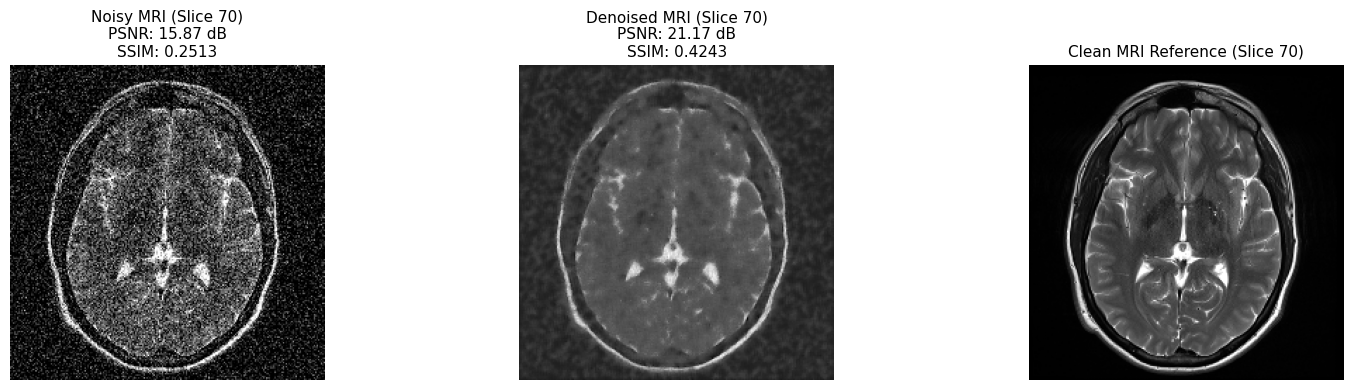

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)

# Ensure the model is in evaluation mode
model.eval()

# 1. Select a new slice index (e.g., slice 70)
new_slice_idx = 70 # Can be changed to any valid slice index within the volume

# Ensure the selected slice is within the volume dimensions
if new_slice_idx < 0 or new_slice_idx >= volume.shape[2]:
    print(f"Error: Selected slice index {new_slice_idx} is out of bounds for volume shape {volume.shape}")
else:
    # 2. Extract the new slice from the original volume
    new_image_2d = volume[:, :, new_slice_idx].astype(np.float32)

    # 3. Apply min-max normalization to the new slice
    # This is consistent with how the training data (image_minmax) was prepared
    new_image_minmax = (
        new_image_2d - new_image_2d.min()
    ) / (
        new_image_2d.max() - new_image_2d.min() + 1e-8
    )

    # 4. Add noise to the normalized new slice
    # Use the same noise type and level as defined previously in the notebook
    # 'add_noise' function returns a PyTorch tensor, assuming it's available
    # from previous cells.
    new_noisy_image_tensor = add_noise(
        new_image_minmax,
        noise_type=noise_type, # 'gauss' or 'poiss' from previous cells
        noise_level=noise_level # e.g., 50, from previous cells
    )

    # 5. Prepare tensors for the model (B x C x H x W) and move to device
    new_noisy_input = new_noisy_image_tensor.unsqueeze(0).unsqueeze(0).to(device)
    new_clean_target = torch.from_numpy(new_image_minmax).float().unsqueeze(0).unsqueeze(0).to(device)

    print(f"\nProcessing slice {new_slice_idx}:")
    print(f"New Noisy Input tensor shape: {new_noisy_input.shape}")
    print(f"New Clean Target tensor shape: {new_clean_target.shape}")

    # 6. Run inference with the trained model
    with torch.no_grad():
        new_denoised_output = model(new_noisy_input)

    # 7. Convert tensors to NumPy for evaluation and visualization
    new_noisy_np = new_noisy_input.squeeze().detach().cpu().numpy()
    new_denoised_np = new_denoised_output.squeeze().detach().cpu().numpy()
    new_clean_np = new_clean_target.squeeze().detach().cpu().numpy()

    # 8. Calculate PSNR and SSIM
    data_range = new_clean_np.max() - new_clean_np.min()

    psnr_noisy_new = peak_signal_noise_ratio(new_clean_np, new_noisy_np, data_range=data_range)
    psnr_denoised_new = peak_signal_noise_ratio(new_clean_np, new_denoised_np, data_range=data_range)
    psnr_improvement_new = psnr_denoised_new - psnr_noisy_new

    ssim_noisy_new = structural_similarity(new_clean_np, new_noisy_np, data_range=data_range)
    ssim_denoised_new = structural_similarity(new_clean_np, new_denoised_np, data_range=data_range)
    ssim_improvement_new = ssim_denoised_new - ssim_noisy_new

    # 9. Print quantitative results
    print("=" * 60)
    print(f"DENOISING EVALUATION FOR SLICE {new_slice_idx}")
    print("=" * 60)
    print(f"PSNR - Noisy:       {psnr_noisy_new:.2f} dB")
    print(f"PSNR - Denoised:    {psnr_denoised_new:.2f} dB")
    print(f"PSNR Improvement:   {psnr_improvement_new:+.2f} dB")
    print("-" * 60)
    print(f"SSIM - Noisy:       {ssim_noisy_new:.4f}")
    print(f"SSIM - Denoised:    {ssim_denoised_new:.4f}")
    print(f"SSIM Improvement:   {ssim_improvement_new:+.4f}")
    print("=" * 60)

    # 10. Visual comparison
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))

    ax[0].imshow(new_noisy_np.T, cmap="gray", origin='lower')
    ax[0].set_title(
        f"Noisy MRI (Slice {new_slice_idx})\n"
        f"PSNR: {psnr_noisy_new:.2f} dB\n"
        f"SSIM: {ssim_noisy_new:.4f}",
        fontsize=11
    )

    ax[1].imshow(new_denoised_np.T, cmap="gray", origin='lower')
    ax[1].set_title(
        f"Denoised MRI (Slice {new_slice_idx})\n"
        f"PSNR: {psnr_denoised_new:.2f} dB\n"
        f"SSIM: {ssim_denoised_new:.4f}",
        fontsize=11
    )

    ax[2].imshow(new_clean_np.T, cmap="gray", origin='lower')
    ax[2].set_title(
        f"Clean MRI Reference (Slice {new_slice_idx})",
        fontsize=11
    )

    for a in ax:
        a.axis("off")

    plt.tight_layout()
    plt.show()

# Exercise;

    Try thresholding the input image after adding synthetic
    noise and re-run the training and input preprocessing onwards.


Processing slice 70:
New Noisy Input tensor shape: torch.Size([1, 1, 224, 224])
New Clean Target tensor shape: torch.Size([1, 1, 224, 224])
DENOISING EVALUATION FOR SLICE 70
PSNR - Noisy:       15.83 dB
PSNR - Denoised:    21.34 dB
PSNR Improvement:   +5.51 dB
------------------------------------------------------------
SSIM - Noisy:       0.2506
SSIM - Denoised:    0.4276
SSIM Improvement:   +0.1770


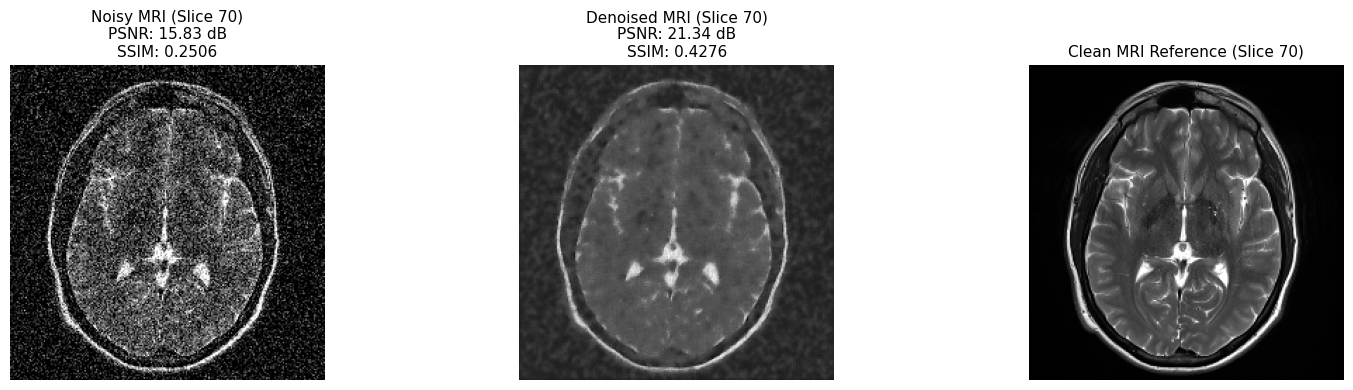

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)

# Ensure the model is in evaluation mode
model.eval()

# 1. Select a new slice index (e.g., slice 70)
new_slice_idx = 70 # Can be changed to any valid slice index within the volume

# Ensure the selected slice is within the volume dimensions
if new_slice_idx < 0 or new_slice_idx >= volume.shape[2]:
    print(f"Error: Selected slice index {new_slice_idx} is out of bounds for volume shape {volume.shape}")
else:
    # 2. Extract the new slice from the original volume
    new_image_2d = volume[:, :, new_slice_idx].astype(np.float32)

    # 3. Apply min-max normalization to the new slice
    # This is consistent with how the training data (image_minmax) was prepared
    new_image_minmax = (
        new_image_2d - new_image_2d.min()
    ) / (
        new_image_2d.max() - new_image_2d.min() + 1e-8
    )

    # 4. Add noise to the normalized new slice
    # Use the same noise type and level as defined previously in the notebook
    # 'add_noise' function returns a PyTorch tensor, assuming it's available
    # from previous cells.
    # new_noisy_image_tensor = add_noise(
    #     new_image_minmax,
    #     noise_type=noise_type,
    #     noise_level=noise_level
    # )

    # 4b. THRESHOLDING STEP
    noise_threshold = 0.05

    # Set all pixels below the threshold strictly to 0.0
    new_noisy_image_tensor = torch.where(
        new_noisy_image_tensor > noise_threshold,
        new_noisy_image_tensor,
        torch.zeros_like(new_noisy_image_tensor)
    )

    # 5. Prepare tensors for the model (B x C x H x W) and move to device
    new_noisy_input = new_noisy_image_tensor.unsqueeze(0).unsqueeze(0).to(device)
    new_clean_target = torch.from_numpy(new_image_minmax).float().unsqueeze(0).unsqueeze(0).to(device)

    print(f"\nProcessing slice {new_slice_idx}:")
    print(f"New Noisy Input tensor shape: {new_noisy_input.shape}")
    print(f"New Clean Target tensor shape: {new_clean_target.shape}")

    # 6. Run inference with the trained model
    with torch.no_grad():
        new_denoised_output = model(new_noisy_input)

    # 7. Convert tensors to NumPy for evaluation and visualization
    new_noisy_np = new_noisy_input.squeeze().detach().cpu().numpy()
    new_denoised_np = new_denoised_output.squeeze().detach().cpu().numpy()
    new_clean_np = new_clean_target.squeeze().detach().cpu().numpy()

    # 8. Calculate PSNR and SSIM
    data_range = new_clean_np.max() - new_clean_np.min()

    psnr_noisy_new = peak_signal_noise_ratio(new_clean_np, new_noisy_np, data_range=data_range)
    psnr_denoised_new = peak_signal_noise_ratio(new_clean_np, new_denoised_np, data_range=data_range)
    psnr_improvement_new = psnr_denoised_new - psnr_noisy_new

    ssim_noisy_new = structural_similarity(new_clean_np, new_noisy_np, data_range=data_range)
    ssim_denoised_new = structural_similarity(new_clean_np, new_denoised_np, data_range=data_range)
    ssim_improvement_new = ssim_denoised_new - ssim_noisy_new

    # 9. Print quantitative results
    print("=" * 60)
    print(f"DENOISING EVALUATION FOR SLICE {new_slice_idx}")
    print("=" * 60)
    print(f"PSNR - Noisy:       {psnr_noisy_new:.2f} dB")
    print(f"PSNR - Denoised:    {psnr_denoised_new:.2f} dB")
    print(f"PSNR Improvement:   {psnr_improvement_new:+.2f} dB")
    print("-" * 60)
    print(f"SSIM - Noisy:       {ssim_noisy_new:.4f}")
    print(f"SSIM - Denoised:    {ssim_denoised_new:.4f}")
    print(f"SSIM Improvement:   {ssim_improvement_new:+.4f}")
    print("=" * 60)

    # 10. Visual comparison
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))

    ax[0].imshow(new_noisy_np.T, cmap="gray", origin='lower')
    ax[0].set_title(
        f"Noisy MRI (Slice {new_slice_idx})\n"
        f"PSNR: {psnr_noisy_new:.2f} dB\n"
        f"SSIM: {ssim_noisy_new:.4f}",
        fontsize=11
    )

    ax[1].imshow(new_denoised_np.T, cmap="gray", origin='lower')
    ax[1].set_title(
        f"Denoised MRI (Slice {new_slice_idx})\n"
        f"PSNR: {psnr_denoised_new:.2f} dB\n"
        f"SSIM: {ssim_denoised_new:.4f}",
        fontsize=11
    )

    ax[2].imshow(new_clean_np.T, cmap="gray", origin='lower')
    ax[2].set_title(
        f"Clean MRI Reference (Slice {new_slice_idx})",
        fontsize=11
    )

    for a in ax:
        a.axis("off")

    plt.tight_layout()
    plt.show()

# The conceptual transition -- Supervised to self-supervised;

### Supervised denoising

```text
Noisy MRI ──→ CNN ──→ Clean MRI
                         ↑
                      TARGET

      # 3. Calculate loss --> with supervised manner
          loss = F.mse_loss(prediction, **clean**)
```

### zero-shot/self-supervised denoising

```text
                 SAME noisy MRI
                       │
              create internal views/Loss variations/...
                       │
                  CNN training
                       │
              consistency / residual
                       │
                denoised MRI
```

The important question is no longer:

> "Where do we get a clean target?"

It becomes:

> **"How can the noisy image itself provide a useful training signal?"**


# Small excercises

    Small Excercises for Making new CNN model 2D and 3D;

    Small examples for making new loss function;

    Examples useful for the zero-shot model training;

**Exercise: Build a Small CNN for MRI Denoising**

Task: Complete the missing parts of the network and implement the forward() function.

Input:

Noisy MRI: [B, 1, 128, 128]

Output:

Denoised MRI: [B, 1, 128, 128]

Architecture:

                 ┌───────────────────────┐
                 │     Input MRI         │
                 │      1 × 128 × 128    │
                 └──────────┬────────────┘
                            ↓
                     Conv 3×3
                            ↓
                    32 × 128 × 128
                            ↓
                     MaxPool 2×2
                            ↓
                     32 × 64 × 64
                            ↓
                     Conv 3×3
                            ↓
                    64 × 64 × 64
                            ↓
                     MaxPool 2×2
                            ↓
                     64 × 32 × 32
                            ↓
                       Conv 3×3
                            ↓
                   128 × 32 × 32
                            ↓
                  Upsample ×2
                            ↓
                   128 × 64 × 64
                            ↓
                     Conv 3×3
                            ↓
                    64 × 64 × 64
                            ↓
                  Upsample ×2
                            ↓
                  64 × 128 × 128
                            ↓
                     Conv 3×3
                            ↓
                     1 × 128 × 128
                            ↓
                    Denoised MRI

## Number of Parameters

The number of parameters tells us how many trainable weights and biases are present in the neural network.

We can calculate the total number of parameters using PyTorch:

```python
total_params = sum(p.numel() for p in model.parameters())

print("Number of parameters:", total_params)

    ## 🧮 Example: Number of Parameters in a CNN Layer

    self.conv1 = nn.Conv2d(
        in_channels=1,
        out_channels=32,
        kernel_size=3,
        padding=1
    )

Exercise: Compute number of parameter in the above layer.

In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class SmallDenoisingCNN(nn.Module):

    def __init__(self):
        super().__init__()

        # -------------------------
        # Encoder
        # -------------------------
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # -------------------------
        # Bottleneck
        # -------------------------
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # -------------------------
        # Decoder
        # -------------------------
        self.up1 = nn.ConvTranspose2d(
            128, 64, kernel_size=2, stride=2
        )

        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        self.up2 = nn.ConvTranspose2d(
            64, 32, kernel_size=2, stride=2
        )

        self.conv5 = nn.Conv2d(32, 32, kernel_size=3, padding=1)

        # -------------------------
        # Output
        # -------------------------
        self.conv6 = nn.Conv2d(32, 1, kernel_size=3, padding=1)

        # Downsampling
        self.pool = nn.MaxPool2d(kernel_size=2)

    def forward(self, x):

        # -------- Encoder --------

        x = self.conv1(x)
        x = F.relu(x)

        # TODO: Downsample
        x = self.pool(x)

        x = self.conv2(x)
        x = F.relu(x)

        # TODO: Downsample
        x = self.pool(x)

        # -------- Bottleneck --------

        x = self.conv3(x)
        x = F.relu(x)

        # -------- Decoder --------

        # TODO: Upsample
        x = self.up1(x)

        x = self.conv4(x)
        x = F.relu(x)

        # TODO: Upsample
        x = self.up2(x)

        x = self.conv5(x)
        x = F.relu(x)

        # -------- Output --------

        x = self.conv6(x)

        return x

In [54]:
model = SmallDenoisingCNN()

print(model)

# Print a summary assuming a batch size of 1, and an image size of 256x256
summary(model, input_size=(1, 1, 256, 256))

SmallDenoisingCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (up1): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (up2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
  (conv5): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv6): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)


Layer (type:depth-idx)                   Output Shape              Param #
SmallDenoisingCNN                        [1, 1, 256, 256]          --
├─Conv2d: 1-1                            [1, 32, 256, 256]         320
├─MaxPool2d: 1-2                         [1, 32, 128, 128]         --
├─Conv2d: 1-3                            [1, 64, 128, 128]         18,496
├─MaxPool2d: 1-4                         [1, 64, 64, 64]           --
├─Conv2d: 1-5                            [1, 128, 64, 64]          73,856
├─ConvTranspose2d: 1-6                   [1, 64, 128, 128]         32,832
├─Conv2d: 1-7                            [1, 64, 128, 128]         36,928
├─ConvTranspose2d: 1-8                   [1, 32, 256, 256]         8,224
├─Conv2d: 1-9                            [1, 32, 256, 256]         9,248
├─Conv2d: 1-10                           [1, 1, 256, 256]          289
Total params: 180,193
Trainable params: 180,193
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 2.93
Input size (MB): 0.

In [55]:
for name, param in model.named_parameters():
    print(
        f"{name:25s} "
        f"Shape: {str(tuple(param.shape)):20s} "
        f"Parameters: {param.numel():,}"
    )

conv1.weight              Shape: (32, 1, 3, 3)        Parameters: 288
conv1.bias                Shape: (32,)                Parameters: 32
conv2.weight              Shape: (64, 32, 3, 3)       Parameters: 18,432
conv2.bias                Shape: (64,)                Parameters: 64
conv3.weight              Shape: (128, 64, 3, 3)      Parameters: 73,728
conv3.bias                Shape: (128,)               Parameters: 128
up1.weight                Shape: (128, 64, 2, 2)      Parameters: 32,768
up1.bias                  Shape: (64,)                Parameters: 64
conv4.weight              Shape: (64, 64, 3, 3)       Parameters: 36,864
conv4.bias                Shape: (64,)                Parameters: 64
up2.weight                Shape: (64, 32, 2, 2)       Parameters: 8,192
up2.bias                  Shape: (32,)                Parameters: 32
conv5.weight              Shape: (32, 32, 3, 3)       Parameters: 9,216
conv5.bias                Shape: (32,)                Parameters: 32
conv6.weig

# Explore for 5 minutes using ChatGPT DL training pipeline.

In [67]:
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)
loss_history = []

for step in range(100):

    # 1. Clear old gradients
    optimizer.zero_grad()

    # 2. Forward pass
    prediction = model(noisy)

    # 3. Calculate loss --> with supervised manner
    # This will only be there for supervised models
    loss = F.mse_loss(prediction, clean)

    # 4. Backpropagation
    loss.backward()

    # 5. Update network parameters
    optimizer.step()

    loss_history.append(loss.item())

    print(f"Step {step + 1:02d} | Loss: {loss.item():.6f}")

Step 01 | Loss: 0.044410
Step 02 | Loss: 0.044329
Step 03 | Loss: 0.043125
Step 04 | Loss: 0.041220
Step 05 | Loss: 0.036972
Step 06 | Loss: 0.030906
Step 07 | Loss: 0.024480
Step 08 | Loss: 0.019370
Step 09 | Loss: 0.016868
Step 10 | Loss: 0.018568
Step 11 | Loss: 0.036728
Step 12 | Loss: 0.022524
Step 13 | Loss: 0.021791
Step 14 | Loss: 0.017585
Step 15 | Loss: 0.020771
Step 16 | Loss: 0.018339
Step 17 | Loss: 0.016107
Step 18 | Loss: 0.018287
Step 19 | Loss: 0.018403
Step 20 | Loss: 0.016783
Step 21 | Loss: 0.017358
Step 22 | Loss: 0.018277
Step 23 | Loss: 0.017803
Step 24 | Loss: 0.016631
Step 25 | Loss: 0.016450
Step 26 | Loss: 0.016948
Step 27 | Loss: 0.016149
Step 28 | Loss: 0.015314
Step 29 | Loss: 0.015535
Step 30 | Loss: 0.015527
Step 31 | Loss: 0.014749
Step 32 | Loss: 0.014518
Step 33 | Loss: 0.014867
Step 34 | Loss: 0.014291
Step 35 | Loss: 0.014080
Step 36 | Loss: 0.014268
Step 37 | Loss: 0.013725
Step 38 | Loss: 0.013461
Step 39 | Loss: 0.013522
Step 40 | Loss: 0.012982


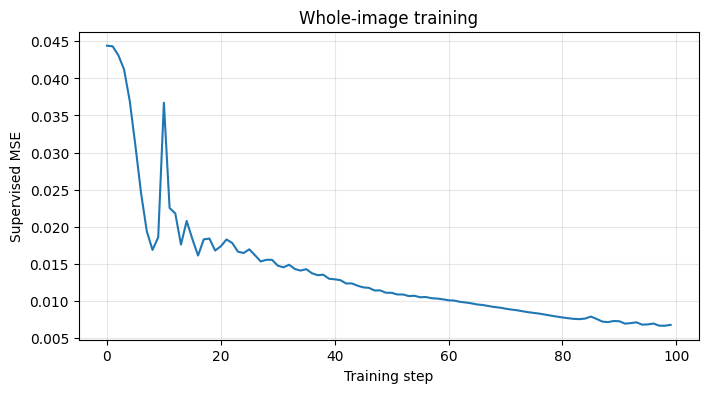

In [68]:
# ============================================================
# 15. Plot training loss
# ============================================================

plt.figure(figsize=(8, 4))

plt.plot(loss_history)

plt.xlabel("Training step")
plt.ylabel("Supervised MSE")
plt.title("Whole-image training")

plt.grid(alpha=0.3)
plt.show()


DENOISING EVALUATION
PSNR - Noisy:       15.28 dB
PSNR - Denoised:    21.86 dB
PSNR Improvement:   +6.57 dB
------------------------------------------------------------
SSIM - Noisy:       0.4019
SSIM - Denoised:    0.7326
SSIM Improvement:   +0.3307


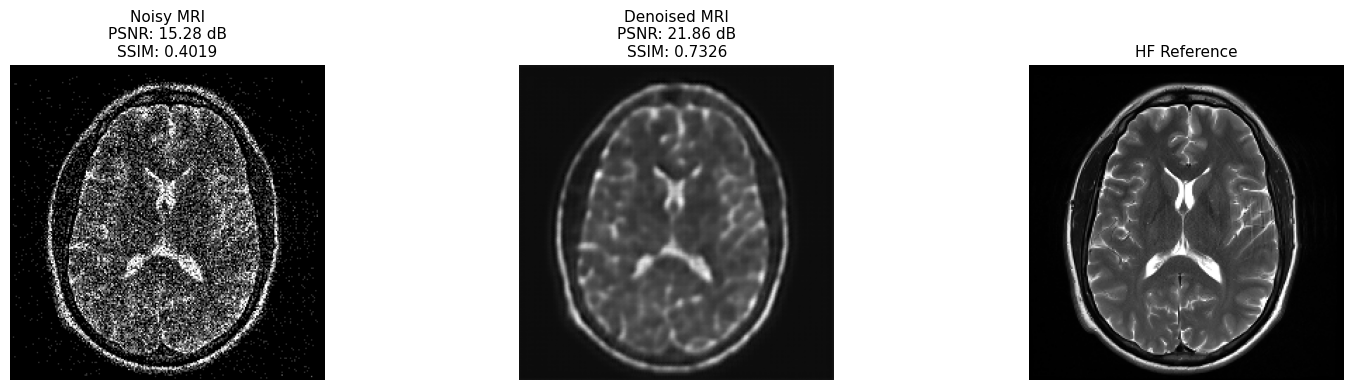

In [69]:
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)


# ------------------------------------------------------------
# 1. Run the trained model
# ------------------------------------------------------------

model.eval()

with torch.no_grad():
    denoised = model(noisy)


# ------------------------------------------------------------
# 2. Convert tensors to NumPy
# ------------------------------------------------------------

noisy_np = noisy.squeeze().detach().cpu().numpy()
# residual_np = residual.squeeze().detach().cpu().numpy()
denoised_np = denoised.squeeze().detach().cpu().numpy()
clean_np = clean.squeeze().detach().cpu().numpy()


# ------------------------------------------------------------
# 3. Define intensity range
# ------------------------------------------------------------

data_range = clean_np.max() - clean_np.min()


# ------------------------------------------------------------
# 4. Calculate PSNR
# ------------------------------------------------------------

psnr_noisy = peak_signal_noise_ratio(
    clean_np,
    noisy_np,
    data_range=data_range
)

psnr_denoised = peak_signal_noise_ratio(
    clean_np,
    denoised_np,
    data_range=data_range
)

psnr_improvement = psnr_denoised - psnr_noisy


# ------------------------------------------------------------
# 5. Calculate SSIM
# ------------------------------------------------------------

ssim_noisy = structural_similarity(
    clean_np,
    noisy_np,
    data_range=data_range
)

ssim_denoised = structural_similarity(
    clean_np,
    denoised_np,
    data_range=data_range
)

ssim_improvement = ssim_denoised - ssim_noisy


# ------------------------------------------------------------
# 6. Print quantitative results
# ------------------------------------------------------------

print("=" * 60)
print("DENOISING EVALUATION")
print("=" * 60)

print(f"PSNR - Noisy:       {psnr_noisy:.2f} dB")
print(f"PSNR - Denoised:    {psnr_denoised:.2f} dB")
print(f"PSNR Improvement:   {psnr_improvement:+.2f} dB")

print("-" * 60)

print(f"SSIM - Noisy:       {ssim_noisy:.4f}")
print(f"SSIM - Denoised:    {ssim_denoised:.4f}")
print(f"SSIM Improvement:   {ssim_improvement:+.4f}")

print("=" * 60)


# ------------------------------------------------------------
# 7. Visual comparison
# ------------------------------------------------------------

fig, ax = plt.subplots(1, 3, figsize=(16, 4))


# Noisy MRI
ax[0].imshow(noisy_np.T, cmap="gray", origin = 'lower')
ax[0].set_title(
    f"Noisy MRI\n"
    f"PSNR: {psnr_noisy:.2f} dB\n"
    f"SSIM: {ssim_noisy:.4f}",
    fontsize=11
)


# Denoised MRI
ax[1].imshow(denoised_np.T, cmap="gray", origin = 'lower')
ax[1].set_title(
    f"Denoised MRI\n"
    f"PSNR: {psnr_denoised:.2f} dB\n"
    f"SSIM: {ssim_denoised:.4f}",
    fontsize=11
)


# HF reference
ax[2].imshow(clean_np.T, cmap="gray", origin = 'lower')
ax[2].set_title(
    "HF Reference",
    fontsize=11
)


# Remove axes
for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()